# Turbulence synthesis: MGD and MGD regularised (Guth method) 

This notebook analyses a 1D turbulence synthesis run produced by `run_SDE.py` (chosen by `CONFIG` below) and compares MGD theta trajectories with the regularised trajectories when the run has them.

In [1]:
import torch
import numpy as np
import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats, ndimage
import math 

import sys
from pathlib import Path

import hashlib
from datetime import datetime
from types import SimpleNamespace

root = Path.cwd()
print(root)

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from utils_experiment import * 
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

root = Path.cwd()
print(root) 

/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence
device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


## Run to analyse
Loads a run already produced by `run_SDE.py` (by its exact config name) instead of running one here.
Data preprocessing, n1, the filters and the SDE parameters below are all read from that run's `config.json`.

In [2]:
import json

CONFIG = ('turbulencesynth_M256_J8_Q3_sigma3.5_nt60000_n1_8500_lam0.0_thomas_nsub1_f64_dedupfilt1e-08'
          '_seed_900_terms2f1130a8_zfloor_two_phase_reg1e-4_20260928_1545')   # SLURM job 272923

exp_dirs = list((root / 'experiments').glob(f'*/{CONFIG}'))
assert exp_dirs, f'no experiments/*/{CONFIG} folder'
exp_dir = exp_dirs[0]
cfg = json.loads((exp_dir / 'config.json').read_text())
fig_dir = exp_dir / 'figures'
fig_dir.mkdir(exist_ok=True)
label = cfg['label']
print(exp_dir)
print({k: cfg.get(k) for k in ('n1', 'subseries_len', 'target_len', 'nt', 'schedule', 'regularization',
                                'lam', 'skip_reg_solve', 'seed')})

/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence/experiments/turbulencesynth_M256_J8_Q3_sigma3.5_nt60000_n1_8500_lam0.0_thomas_nsub1_f64_dedupfilt1e-08_terms2f1130a8_zfloor_two_phase_reg1e-4/turbulencesynth_M256_J8_Q3_sigma3.5_nt60000_n1_8500_lam0.0_thomas_nsub1_f64_dedupfilt1e-08_seed_900_terms2f1130a8_zfloor_two_phase_reg1e-4_20260928_1545
{'n1': 8500, 'subseries_len': 512, 'target_len': 256, 'nt': 60000, 'schedule': 'two_phase', 'regularization': 0.0001, 'lam': 0.0, 'skip_reg_solve': True, 'seed': 900}


## Data preprocessing

In [3]:
# Orthogonal wavelet
W = DefineWavelet('Db', m=3, device=device)

Data = load_turbulence_1d()
print(Data.shape) 

n = cfg['subseries_len']
Data = split_periodize_reshape(Data, n)

for j in range(int(np.log2(n / cfg['target_len']))):   # as run_SDE.py: coarse-grain down to target_len
    Data = W.decompose(Data)[1]

n1 = cfg['n1']
x1 = normalize(Data[:n1]).to(device)
print('Data shape after preprocessing:', Data.shape)
print('x1 shape:', x1.shape) 

torch.Size([10000, 1, 1800])
Data shape after preprocessing: torch.Size([30000, 1, 256])
x1 shape: torch.Size([8500, 1, 256])


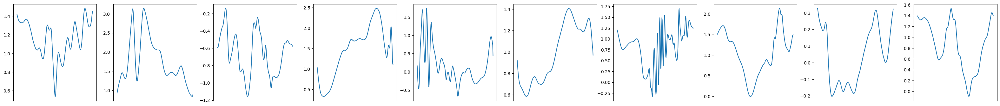

In [4]:
%matplotlib inline 
plot_time_series_row(x1, 10)

## Scaling exponent ratio of original data

Computing structure functions for 24 lags...
Loaded structure functions from cache!


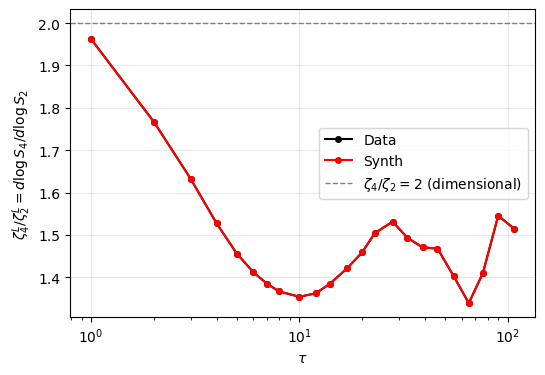

(array([  1,   2,   3,   4,   5,   6,   7,   8,  10,  12,  14,  17,  20,
         23,  28,  33,  39,  46,  55,  65,  76,  90, 107]),
 array([1.96213539, 1.76701177, 1.63291407, 1.52740827, 1.45594555,
        1.41229674, 1.38413731, 1.36639773, 1.35377093, 1.36225839,
        1.38461084, 1.42166978, 1.45893041, 1.50396214, 1.53132613,
        1.49306431, 1.47053674, 1.46779766, 1.40260121, 1.33888128,
        1.41000027, 1.54541184, 1.51493276]),
 array([1.96213539, 1.76701177, 1.63291407, 1.52740827, 1.45594555,
        1.41229674, 1.38413731, 1.36639773, 1.35377093, 1.36225839,
        1.38461084, 1.42166978, 1.45893041, 1.50396214, 1.53132613,
        1.49306431, 1.47053674, 1.46779766, 1.40260121, 1.33888128,
        1.41000027, 1.54541184, 1.51493276]))

In [7]:
# scaling exponent ratio 
%matplotlib inline 
scaling_exponent_ratio_compare(x1, x1, 30, kill_points=1)

## Shared model/SDE parameters

In [5]:
B, channels, M = x1.shape
print(f'(B, C, T) = ({B}, {channels}, {M}).')
assert M == cfg['M'] and B == cfg['B'], 'x1 does not match the run'

J = cfg['J']
Q = cfg['Q']

filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
filters_Q = return_Filters(M, J, Q, device=device)

print("filters shape:", filters.shape) 
print("filters_Q shape:", filters_Q.shape) 

interpolant = cfg['interpolant']
sigma = cfg['sigma']
terms = cfg['terms']

result = try_load_experiment(root, CONFIG, device)
assert result is not None, f'{CONFIG} not in saved_results/: pull it first'
loaded = result
t = result['t']      # the grid the run actually used (two_phase / adaptive grids are not uniform)
print(f"{tuple(result['xt'].shape)}, {len(t) - 1} steps, t_end = {float(t[-1]):.8f}")
print('Theta_reg:', 'none (run used --skip_reg_solve)' if result['Theta_reg'] is None
      else tuple(result['Theta_reg'].shape))

(B, C, T) = (8500, 1, 256).
filters shape: torch.Size([1, 9, 256])
filters_Q shape: torch.Size([1, 25, 256])
(8500, 1, 256), 60000 steps, t_end = 0.99995000
Theta_reg: none (run used --skip_reg_solve)


(0.0, 20.0)

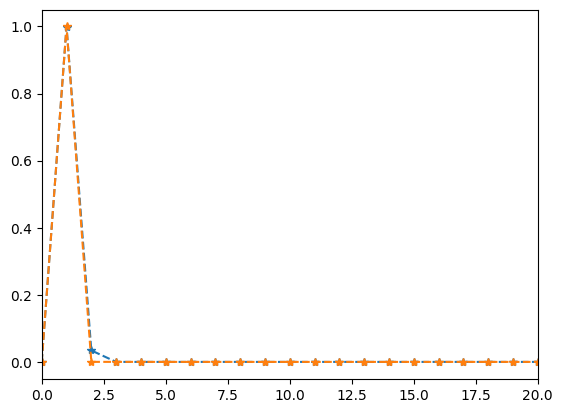

In [10]:
plt.plot(filters[0,7,:].cpu(), "--*") 
plt.plot(filters_Q[0,20,:].cpu(), "--*") 
plt.xlim(0,20) 

## Check wavelet coefficients histograms, Q=3

torch.Size([8500, 25, 256])


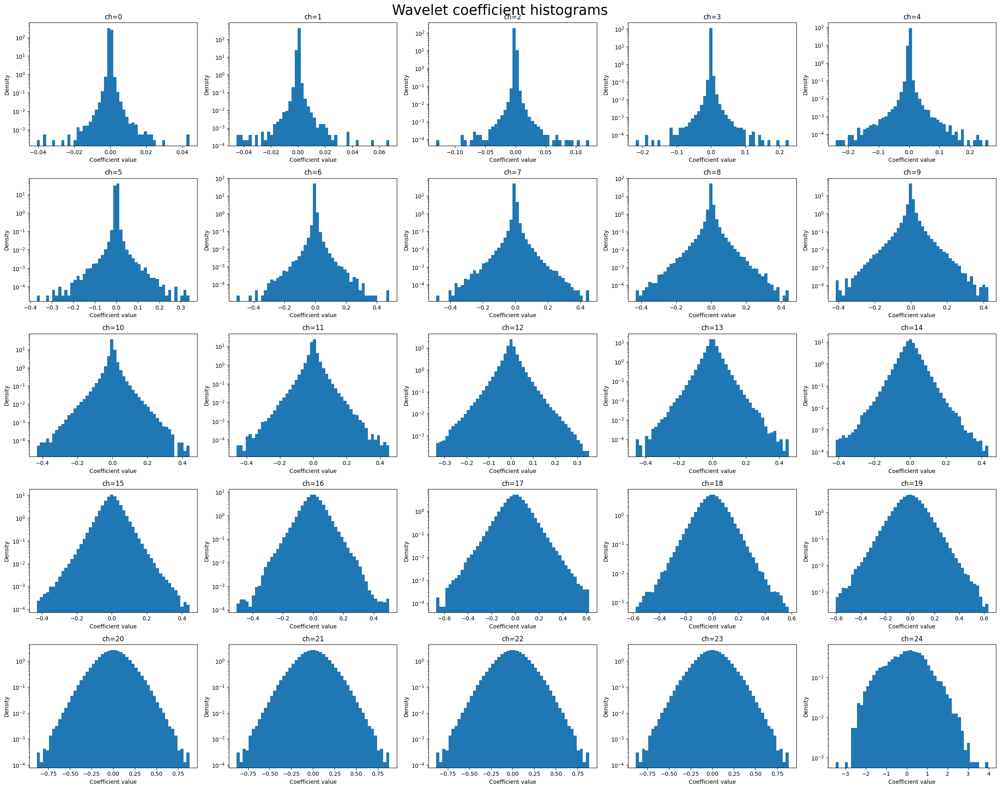

In [9]:
%matplotlib inline 
wt = torch.fft.ifft(torch.fft.fft(x1) * filters_Q).real  # (B, J, T)
print(wt.shape) 
n_wavelets = filters_Q.shape[1]
# ------------------------------------------------------------------
# 1. Overview grid
# ------------------------------------------------------------------
ncols = 5
nrows = math.ceil(n_wavelets / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for i in range(n_wavelets):
    vals = wt[:, i, :].detach().cpu().flatten().numpy()
    axes[i].hist(vals, bins=50, density=True, log=True)
    axes[i].set_title(f"ch={i}")
    axes[i].set_xlabel("Coefficient value")
    axes[i].set_ylabel("Density")
for j in range(n_wavelets, len(axes)):
    axes[j].axis("off")
plt.suptitle(f"Wavelet coefficient histograms", fontsize=25)
plt.tight_layout()
plt.show()

## Check how the model fits data

## Run or load an experiment
Set `FORCE_RERUN = True` if you want to recompute samples even when saved results already exist.

The standard outputs are saved with your existing `save_results(...)`. In addition, this notebook saves a small auxiliary `.pt` file containing `barphi_e` and `barphi_p`, because these are useful for plotting moment matching after reloading.

### find where $t_i$ switches to 1.0 and choose that as final time point for the run
Otherwise the regularized results will be $Nan$

In [5]:
if loaded is None:   # only for a new run on the linear grid; a loaded run keeps its own grid
    t_rounded = torch.round(t, decimals=4)
    t_final = int((t_rounded == 1.0).nonzero(as_tuple=True)[0][0]) 
    print(f"t_final = {t_final}/{len(t)} (last t = {t[t_final-1].item():.6f}, "
          f"dropping {len(t) - t_final} redundant trailing points at 1.0000)")

In [6]:
if loaded is not None:
    result = loaded
    print("experiment already exists, loaded.") 
else:
    result = run_experiment(args, M, config, x1, filters, t[:t_final],
                            logger, root, device=device,
                            filters_Q=filters_Q, filters_Phi=filters_Phi,
                            potentials_save_dir=potentials_dir)

experiment already exists, loaded.


# Analyze results 

In [7]:
theta_t = result['theta_t']
print(theta_t.shape, theta_t.device)
theta_reg_t = result['Theta_reg']

torch.Size([60000, 281]) cpu


In [8]:
if theta_reg_t is not None:
    print(theta_reg_t[:, 5])

## Coarse grain 

60000 (no Theta_reg)


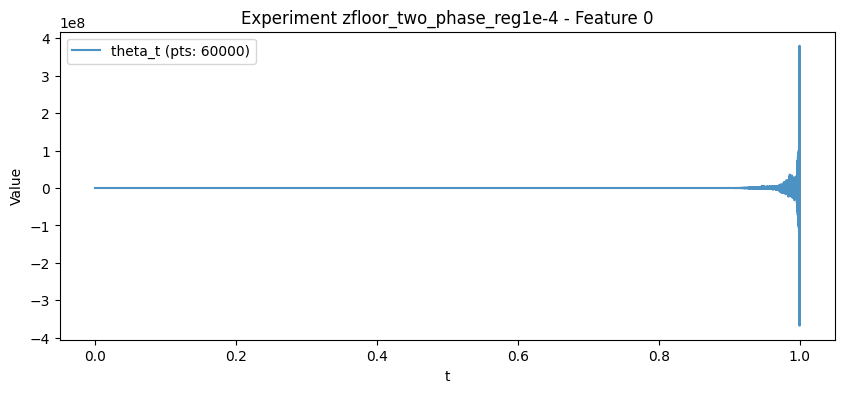

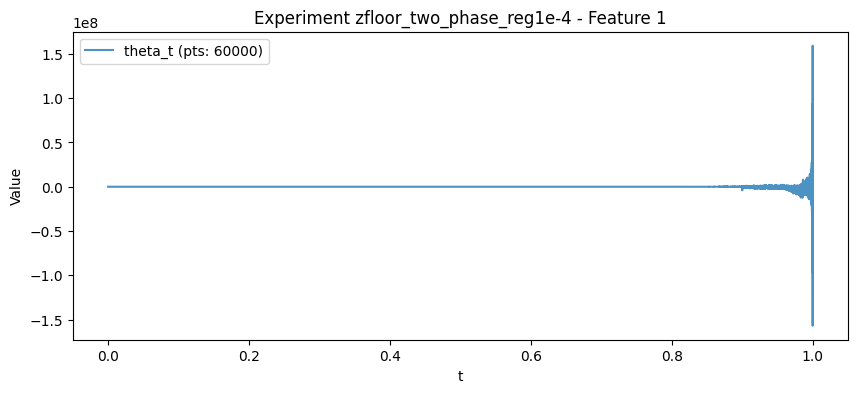

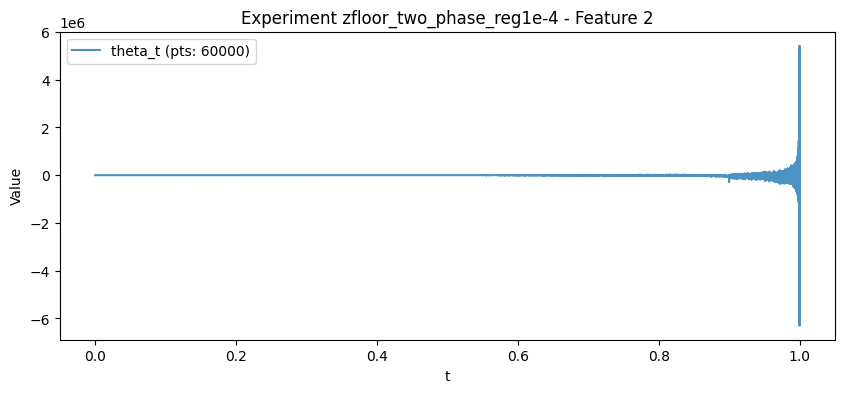

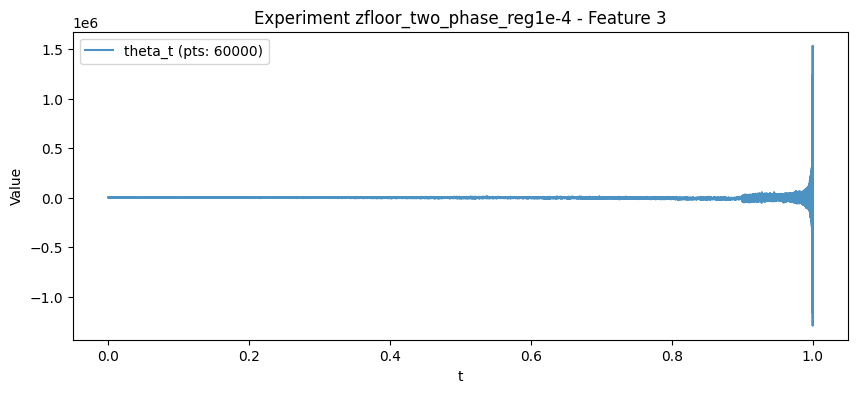

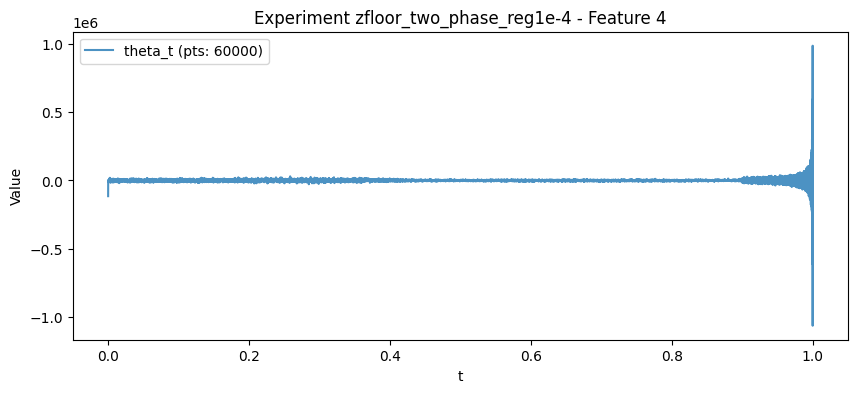

...

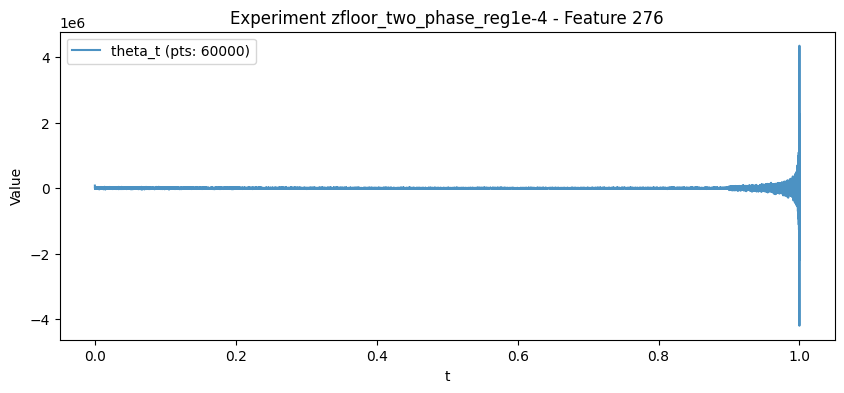

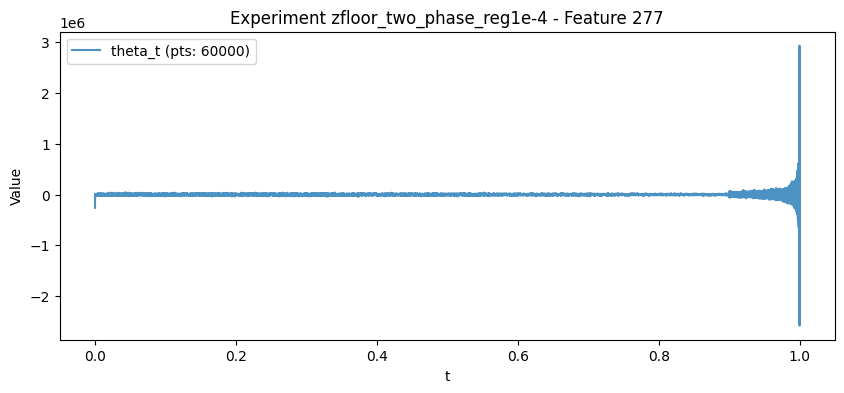

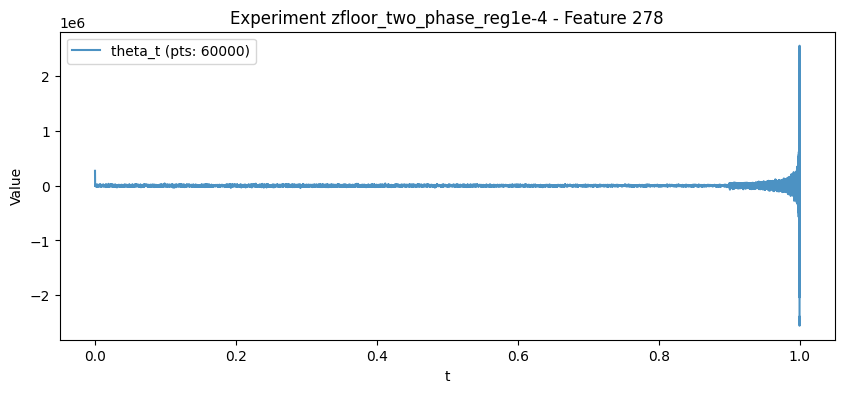

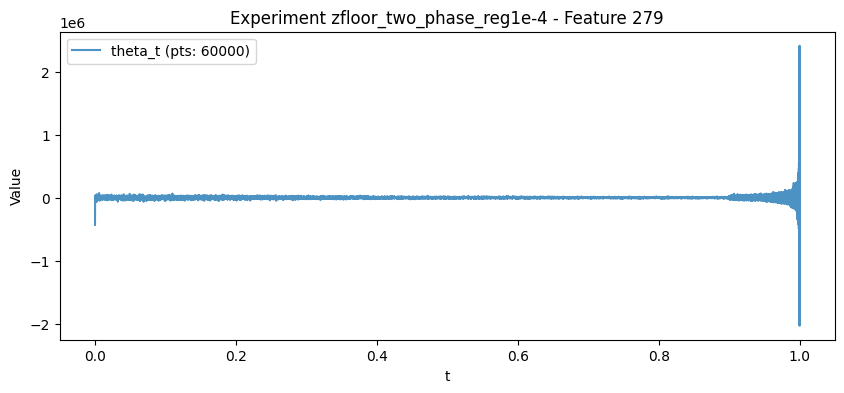

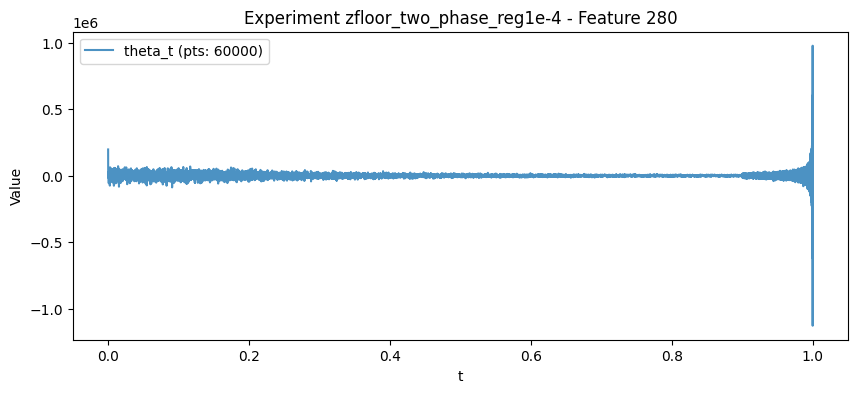

In [9]:
# theta_t[k] is computed at t[k] (the grid has one more point than theta_t), so plot against
# the run's real time grid: two_phase / adaptive grids are far from uniform near t = 1.
import matplotlib.pyplot as plt
theta_t = theta_t.cpu()
t_np = result['t'].detach().cpu().numpy()
len_t = theta_t.shape[0]
x_t = t_np[:len_t]
if theta_reg_t is not None:
    theta_reg_t = theta_reg_t.cpu()
    len_reg = theta_reg_t.shape[0]
    t_reg = result.get('t_reg')
    x_reg = (t_reg.detach().cpu().numpy()[:len_reg] if t_reg is not None
             else np.linspace(x_t[0], x_t[-1], len_reg))   # runs saved before the t_reg fix
    print(len_t, len_reg)
else:
    print(len_t, '(no Theta_reg)')

%matplotlib inline
for i in range(theta_t.shape[1]): 
    plt.figure(figsize=(10, 4))
    plt.plot(x_t, theta_t[:, i], label=f"theta_t (pts: {len_t})", alpha=0.8) 
    if theta_reg_t is not None:
        plt.plot(x_reg, theta_reg_t[:, i], label=f"theta_reg_t (pts: {len_reg})", alpha=0.8) 
    plt.title(f"Experiment {label} - Feature {i}")
    plt.xlabel("t")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

## Moment matching diagnostics

zfloor_two_phase_reg1e-4


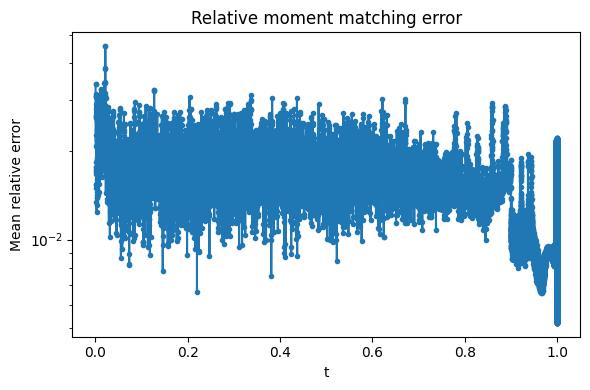

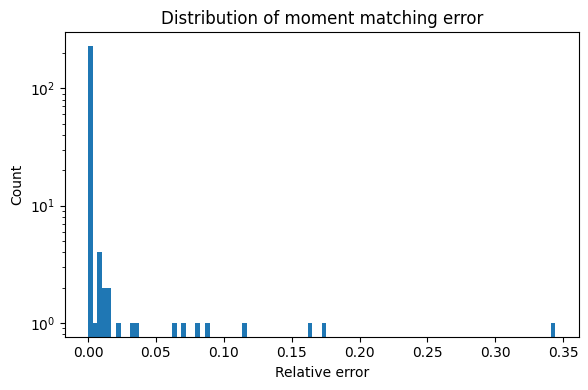

<Figure size 640x480 with 0 Axes>

In [10]:
threshold = 1e-8
%matplotlib inline
print(label)
if result.get('barphi_e') is None or result.get('barphi_p') is None:
    print('Moment matching arrays not available. Set FORCE_RERUN=True or make sure the auxiliary file exists.')
else:
    plot_moment_matching(result['barphi_e'], result['barphi_p'], result['t'], threshold)
    plt.suptitle(label)
    
    plt.show()


In [11]:
def compare_time_series_grid(Data, Synth, n_rows=2, n_cols=8, channel=0,
                             start=0, save=None):
    """Grid of data vs synthesis: n_rows pairs of rows, n_cols series each.

    Each pair is a Data row (grey) above a Synth row (blue), taking series
    start + r*n_cols ... start + (r+1)*n_cols - 1. All panels share one y
    range so amplitudes are directly comparable; no markers, minimal ticks.
    """
    to_np = lambda a: a.detach().cpu().numpy() if hasattr(a, "detach") else np.asarray(a)
    D = to_np(Data)[:, channel]
    S = to_np(Synth)[:, channel]
    n_avail = min(len(D), len(S)) - start
    n_rows = min(n_rows, max(n_avail // n_cols, 0))
    if n_rows == 0:
        print(f"compare_time_series_grid: need {n_cols} series from start={start}, "
              f"have {n_avail} — skipping.")
        return
    sl = slice(start, start + n_rows * n_cols)
    both = np.concatenate([D[sl], S[sl]])
    lo, hi = both.min(), both.max()
    pad = 0.05 * (hi - lo)

    fig, axs = plt.subplots(2 * n_rows, n_cols, figsize=(1.9 * n_cols, 1.3 * 2 * n_rows),
                            sharex=True, sharey=True, squeeze=False)
    for r in range(n_rows):
        for (arr, color, label, k) in ((D, "0.35", "Data", 0), (S, "tab:blue", "MGD", 1)):
            for c in range(n_cols):
                ax = axs[2 * r + k, c]
                ax.plot(arr[start + r * n_cols + c], color=color, lw=0.7)
                ax.set_ylim(lo - pad, hi + pad)
                ax.set_xticks([]); ax.set_yticks([])
                for s in ("top", "right"):
                    ax.spines[s].set_visible(False)
            axs[2 * r + k, 0].set_ylabel(label, fontsize=11, color=color)
        if r < n_rows - 1:  # visual gap between row-pairs
            for ax in axs[2 * r + 1]:
                ax.spines["bottom"].set_linewidth(1.5)
    fig.subplots_adjust(wspace=0.05, hspace=0.08)
    if save:
        fig.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()

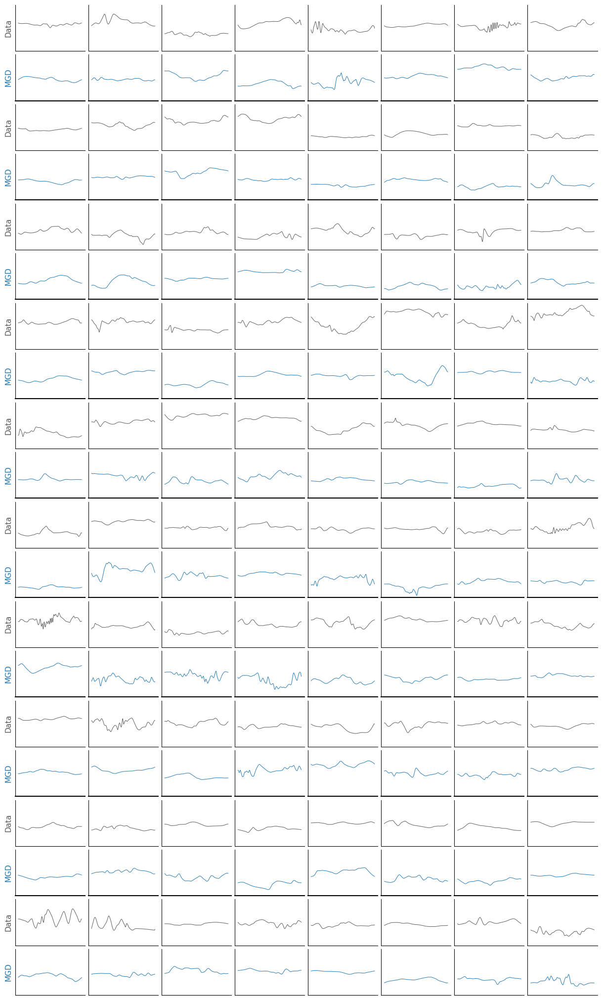

In [19]:
compare_time_series_grid(x1, result['xt'],10,8) 

In [16]:
result['xt'].squeeze(1).reshape(-1).shape 

torch.Size([2176000])

In [29]:
def compare_distributions(Data, Synth, channel=0, orders=(0, 1, 2), dt=1.0,
                          bins=200, standardize=True, save=None):
    """Data vs synthesis PDFs of the signal and its finite differences.

    orders: 0 = signal, 1 = first difference (velocity->acceleration),
            2 = second difference. Log-y PDFs to show the tails, Gaussian of
            the same variance as reference; mean/std/skew/flatness in legend.
    """
    to_np = lambda a: a.detach().cpu().numpy() if hasattr(a, "detach") else np.asarray(a)
    D, S = to_np(Data)[:, channel], to_np(Synth)[:, channel]
    names = {0: "signal", 1: "1st difference", 2: "2nd difference"}

    def stats(v):
        m, s = v.mean(), v.std()
        z = (v - m) / s
        return m, s, (z ** 3).mean(), (z ** 4).mean()

    fig, axs = plt.subplots(1, len(orders), figsize=(5 * len(orders), 4), squeeze=False)
    for ax, o in zip(axs[0], orders):
        d = (np.diff(D, n=o, axis=-1) / dt ** o).ravel() if o else D.ravel()
        s = (np.diff(S, n=o, axis=-1) / dt ** o).ravel() if o else S.ravel()
        sd, ss = stats(d), stats(s)
        if standardize:                      # both on the DATA's scale
            d, s = (d - sd[0]) / sd[1], (s - sd[0]) / sd[1]
        ymax = 0
        edges = np.linspace(min(d.min(), s.min()), max(d.max(), s.max()), bins + 1)
        for v, st, col, lab in ((d, sd, "0.3", "data"), (s, ss, "tab:blue", "MGD")):
            h, _ = np.histogram(v, edges, density=True)
            c = 0.5 * (edges[1:] + edges[:-1])
            ymax = max(ymax, h.max())
            ax.semilogy(c, np.where(h > 0, h, np.nan), color=col, lw=1.3,
                        label=f"{lab}: σ={st[1]:.3g} skew={st[2]:.2f} F={st[3]:.2f}")
        mu, sig = (0, 1) if standardize else sd[:2]
        g = np.exp(-0.5 * ((c - mu) / sig) ** 2) / (sig * np.sqrt(2 * np.pi))
        ax.semilogy(c, g, "k--", lw=0.8, alpha=0.5, label="Gaussian (F=3)")
        ax.set_ylim(0.5 / (len(d) * np.diff(edges)[0]), 3 * ymax)  # ~one-count floor
        ax.set_title(names.get(o, f"order {o} difference"))
        ax.set_xlabel("(x − μ_data) / σ_data" if standardize else "x")
        ax.legend(fontsize=7, frameon=False)
        ax.spines[["top", "right"]].set_visible(False)
    axs[0, 0].set_ylabel("PDF")
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=200, bbox_inches="tight")
    

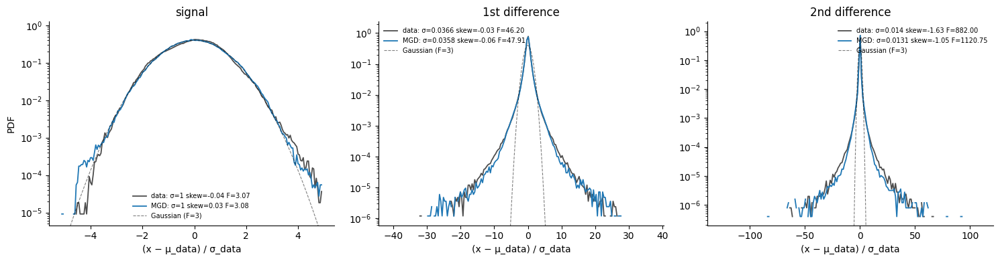

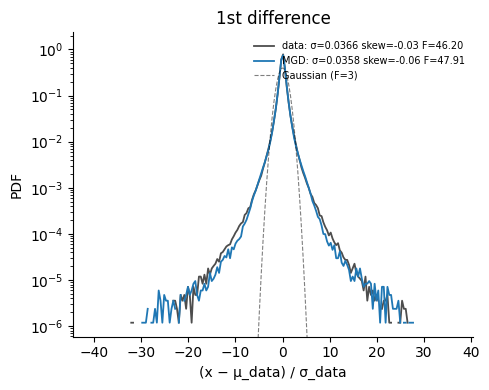

In [32]:
compare_distributions(x1, result['xt'])                    # signal, 1st and 2nd differences
compare_distributions(x1, result['xt'], orders=(1,), dt=1) # acceleration only, in physical units

### Any indentical generated signals? 

In [43]:
def _nn(A, B, exclude_self=False, chunk=1024):
    """Nearest neighbour in B (L2, pointwise) of every row of A."""
    idx, dist = [], []
    for i in range(0, len(A), chunk):
        d = torch.cdist(A[i:i + chunk], B)
        if exclude_self:
            r = torch.arange(i, min(i + chunk, len(A)))
            d[r - i, r] = float("inf")
        m, j = d.min(1)
        idx.append(j); dist.append(m)
    return torch.cat(idx), torch.cat(dist)


def find_duplicates(Data, Synth, channel=0, atol=1e-6, rel_thr=0.3, top=5):
    """Near-duplicates in three settings, all on the same scale:
      data  vs data   -> duplicates already in the dataset (baseline)
      synth vs synth  -> mode collapse (generator repeats itself)
      synth vs data   -> memorisation / overfitting (generator copies data)
    rel = NN distance / median data->data NN distance (~1 normal, << 1 suspicious).
    """
    D = torch.as_tensor(Data)[:, channel].double().flatten(1)
    S = torch.as_tensor(Synth)[:, channel].double().flatten(1)

    pairs = {"data-data": _nn(D, D, exclude_self=True),
             "synth-synth": _nn(S, S, exclude_self=True),
             "synth-data": _nn(S, D)}
    scale = pairs["data-data"][1].median()
    out = {}
    for name, (idx, dist) in pairs.items():
        rel = dist / scale
        n_exact = (dist <= atol * dist.new_tensor(D.shape[1]).sqrt()).sum().item()
        order = rel.argsort()[:top]
        print(f"[{name:11s}] median rel {rel.median():.3f} | "
              f"rel<{rel_thr}: {(rel < rel_thr).sum().item():4d}/{len(rel)} | exact: {n_exact}")
        print(f"              closest (i -> j, rel): "
              f"{[(i.item(), idx[i].item(), round(rel[i].item(), 4)) for i in order]}")
        out[name] = (idx, dist, rel)
    return out

In [44]:
def plot_closest_pairs(res, Data, Synth, which="synth-data", k=8, channel=0,
                       n_cols=4, save=None):
    """Overlay the k closest pairs from find_duplicates, with their difference.

    Top panel of each pair: the two series overlaid. Bottom panel: difference
    (on its own scale, so tiny differences stay visible), with max|diff|.
    """
    to_np = lambda a: a.detach().cpu().numpy() if hasattr(a, "detach") else np.asarray(a)
    D, S = to_np(Data)[:, channel], to_np(Synth)[:, channel]
    A, B = {"data-data": (D, D), "synth-synth": (S, S), "synth-data": (S, D)}[which]
    la, lb = {"data-data": ("data", "data"), "synth-synth": ("synth", "synth"),
              "synth-data": ("synth", "data")}[which]
    ca, cb = ("tab:blue" if la == "synth" else "0.35"), ("tab:orange" if la == lb else "0.35")

    idx, _, rel = res[which]
    order = rel.argsort()
    if which != "synth-data":                     # drop mirrored (j, i) pairs
        seen, keep = set(), []
        for i in order.tolist():
            p = frozenset((i, idx[i].item()))
            if p not in seen:
                seen.add(p); keep.append(i)
        order = keep
    order = list(order[:k])
    k = len(order)
    n_rows = int(np.ceil(k / n_cols))

    fig, axs = plt.subplots(2 * n_rows, n_cols, figsize=(3.2 * n_cols, 2.6 * n_rows),
                            sharex=True, squeeze=False,
                            gridspec_kw={"height_ratios": [3, 1] * n_rows})
    for n, i in enumerate(order):
        i = int(i); j = idx[i].item()
        r, c = divmod(n, n_cols)
        ax, axd = axs[2 * r, c], axs[2 * r + 1, c]
        ax.plot(B[j], color=cb, lw=1.6, alpha=0.6)
        ax.plot(A[i], color=ca, lw=0.8)
        diff = A[i] - B[j]
        ax.set_title(f"{la} #{i} vs {lb} #{j}\nrel {rel[i].item():.2g}   "
                     f"max|Δ| {np.abs(diff).max():.2g}", fontsize=9)
        axd.plot(diff, color="tab:red", lw=0.7)
        axd.axhline(0, color="0.7", lw=0.5)
        for a in (ax, axd):
            a.set_yticks([]); a.spines[["top", "right"]].set_visible(False)
    for n in range(k, n_rows * n_cols):           # hide unused panels
        r, c = divmod(n, n_cols)
        axs[2 * r, c].axis("off"); axs[2 * r + 1, c].axis("off")
    axs[1, 0].set_ylabel("Δ", fontsize=9)
    fig.suptitle(f"closest {which} pairs — thick: {lb}, thin: {la}, red: difference",
                 fontsize=11)
    fig.tight_layout(h_pad=0.2)
    if save:
        fig.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()

[data-data  ] median rel 1.000 | rel<0.3:   72/8500 | exact: 0
              closest (i -> j, rel): [(5259, 5262, 0.0371), (5262, 5259, 0.0371), (8388, 8391, 0.0517), (8391, 8388, 0.0517), (2664, 3135, 0.0664)]
[synth-synth] median rel 1.013 | rel<0.3:    0/8500 | exact: 0
              closest (i -> j, rel): [(547, 7907, 0.3175), (7907, 547, 0.3175), (135, 4879, 0.3314), (4879, 135, 0.3314), (5236, 7888, 0.3409)]
[synth-data ] median rel 1.024 | rel<0.3:    1/8500 | exact: 0
              closest (i -> j, rel): [(457, 655, 0.2752), (786, 1476, 0.3003), (8094, 5969, 0.3077), (6538, 5801, 0.31), (719, 3584, 0.3348)]


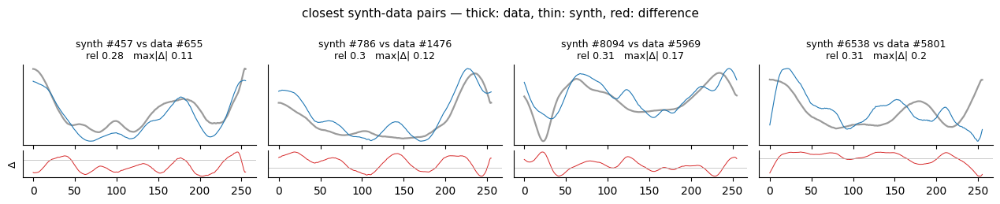

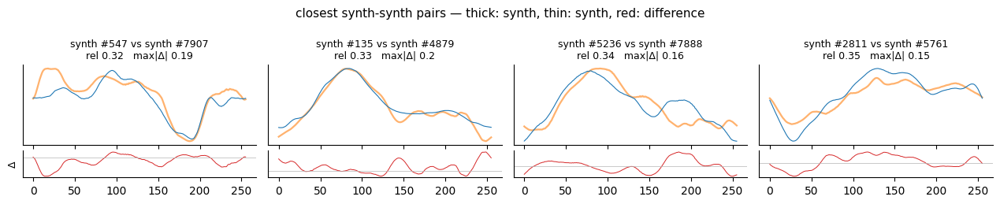

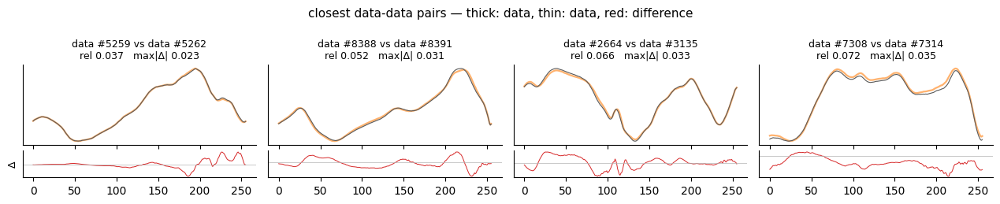

In [46]:
res = find_duplicates(x1, result['xt'])
plot_closest_pairs(res, x1, result['xt'], "synth-data", k=4)    # overfitting
plot_closest_pairs(res, x1, result['xt'], "synth-synth", k=4)   # mode collapse
plot_closest_pairs(res, x1, result['xt'], "data-data", k=4)     # dataset duplicates

## Visual comparison of samples

## Time asymmetry 
Check for time asymmetry by investigating the energy increments distribution and skewness vs tau. 

<Axes: xlabel='$\\tau$', ylabel='Skewness'>

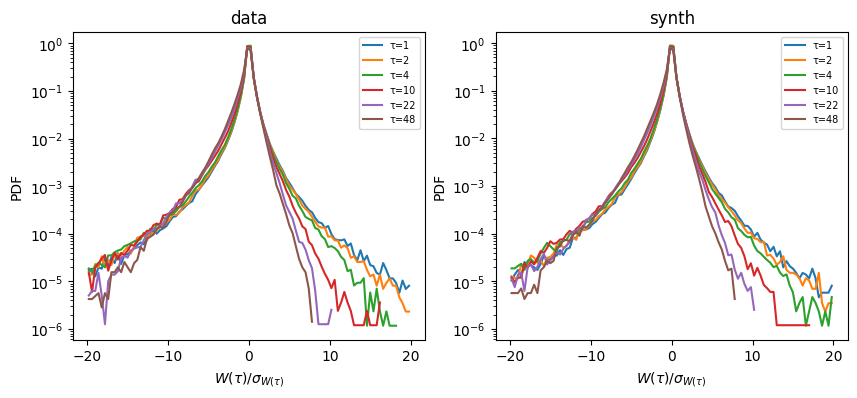

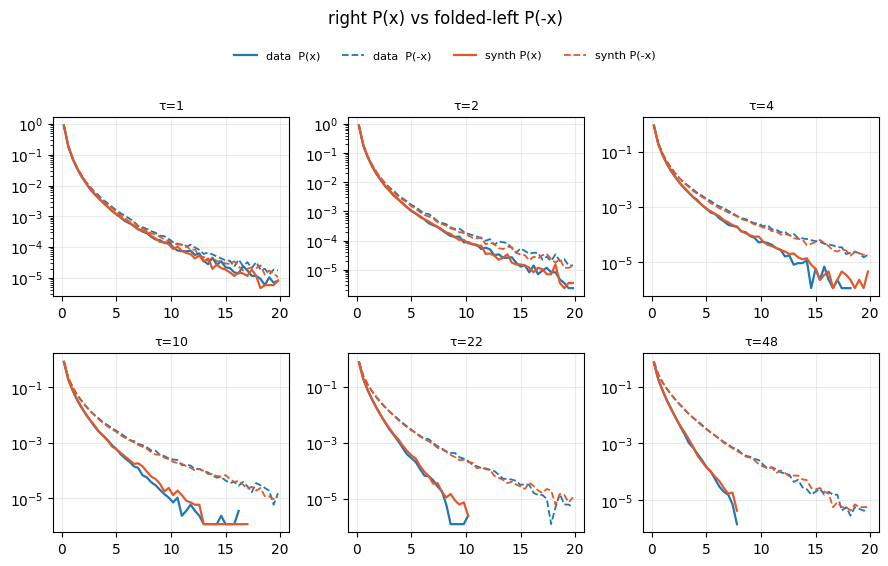

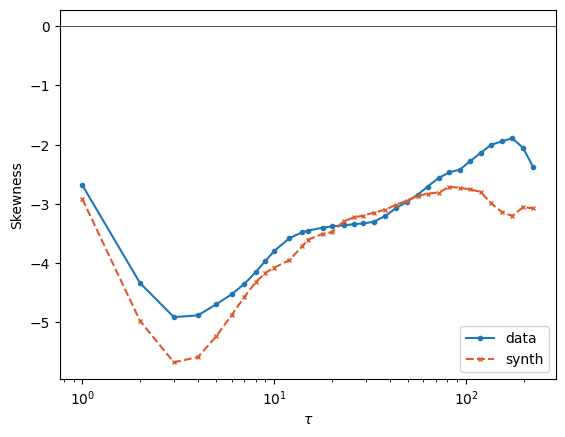

In [17]:
T = x1.shape[-1]
taus = logspaced_taus(50, num_points=6)              # positive only, for PDFs
pdf_data  = pdf_energy_increments(x1, taus, mode="power")
pdf_synth = pdf_energy_increments(result["xt"], taus, mode="power")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_pdf_panel(pdf_data, ax=axes[0], title="data")
plot_pdf_panel(pdf_synth, ax=axes[1], title="synth")

plot_pdf_folded_grid(pdf_data, pdf_synth, title="right P(x) vs folded-left P(-x)")

fig2, ax2 = plt.subplots()
%matplotlib inline
plot_skewness_comparison(x1, result["xt"], ax=ax2)   # positive-only log-x taus by default

## Leverage with C_pq

## Scaling exponent ratio 

Computing structure functions for 24 lags...
Computing structure functions for 24 lags...


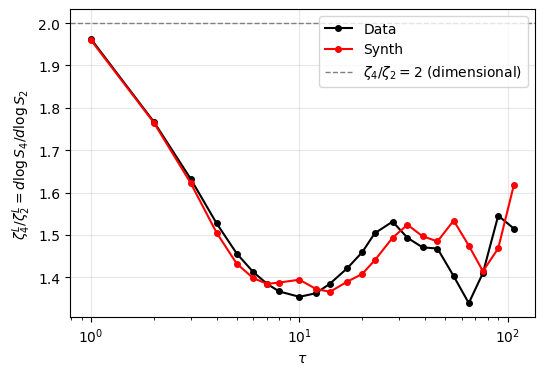

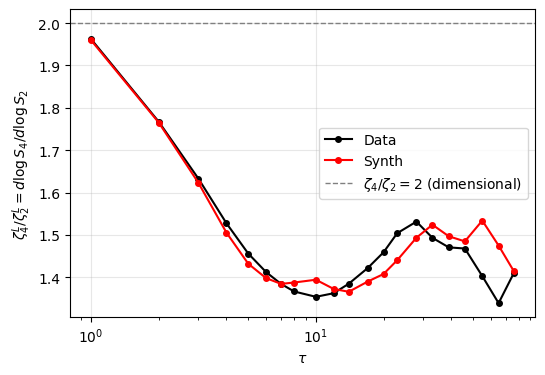

In [22]:
taus, ratio_data, ratio_synth = scaling_exponent_ratio_compare(x1, result['xt'], 30, kill_points=1) 

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(taus[:-2], ratio_data[:-2], 'ko-', ms=4, label='Data')
ax.plot(taus[:-2], ratio_synth[:-2], 'ro-', ms=4, label='Synth')
ax.axhline(2.0, color='grey', ls='--', lw=1, label=r'$\zeta_4/\zeta_2=2$ (dimensional)')
ax.set_xscale('log')
ax.set_xlabel(r'$\tau$')
ax.set_ylabel(r'$\zeta_4^L/\zeta_2^L = d\log S_4 / d\log S_2$')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Wavelet coefficient marginals, structure functions and other diagnostics 

In [19]:

def structure_plot(Data, synth, save=None):
    """
    Plot structure functions S_p(tau) for p in {2,4,6,8}.

    If save is None:
        show the two figures as before.

    If save is provided:
        save both plots into a single figure.
    """

    max_tau = Data.shape[-1] // 2

    second_order = second_order_structure_function(
        Data, p=np.array([2, 4, 6, 8]), max_tau=max_tau
    )
    second_order_gen = second_order_structure_function(
        synth, p=np.array([2, 4, 6, 8]), max_tau=max_tau
    )

    if save is None:

        # ---------- Figure 1 : normalized structure functions ----------
        fig = plt.figure(figsize=(6, 5))
        ax = fig.add_subplot()

        ax.plot(second_order[0], 'b--', label='original_2', ms=3)
        ax.plot(second_order[1] / second_order[0] ** 2, 'r--', label='original_4', ms=3)
        ax.plot(second_order[2] / second_order[0] ** 3, 'g--', label='original_6', ms=3)
        ax.plot(second_order[3] / second_order[0] ** 4, 'y--', label='original_8', ms=3)

        ax.plot(second_order_gen[0], 'bo', label='gen_2')
        ax.plot(second_order_gen[1] / second_order_gen[0] ** 2, 'ro', label='gen_4')
        ax.plot(second_order_gen[2] / second_order_gen[0] ** 3, 'go', label='gen_6')        
        ax.plot(second_order_gen[3] / second_order_gen[0] ** 4, 'yo', label='gen_8')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('tau')
        ax.set_ylabel(r'$S_p/S_2^{p/2}$')
        ax.set_title('Normalized structure functions')
        ax.legend()

        plt.tight_layout()
        plt.show()

        # ---------- Figure 2 : raw structure functions ----------
        fig = plt.figure(figsize=(6, 5))
        ax = fig.add_subplot()

        ax.plot(second_order[0], 'b--', label='original_2', ms=3)
        ax.plot(second_order[1], 'r--', label='original_4', ms=3)
        ax.plot(second_order[2], 'g--', label='original_6', ms=3)        
        ax.plot(second_order[3], 'y--', label='original_8', ms=3)

        ax.plot(second_order_gen[0], 'bo', label='gen_2')
        ax.plot(second_order_gen[1], 'ro', label='gen_4')
        ax.plot(second_order_gen[2], 'go', label='gen_6')
        ax.plot(second_order_gen[3], 'yo', label='gen_8')
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('tau')
        ax.set_ylabel(r'$S_p(\tau)$')
        ax.set_title('Structure functions')
        ax.legend()

        plt.tight_layout()
        plt.show()

    else:

        fig, (ax1, ax2) = plt.subplots(
            1, 2,
            figsize=(12, 4)
        )

        # ---------- Top panel ----------
        ax1.plot(second_order[0], 'b--', label='original_2', ms=3)
        ax1.plot(second_order[1] / second_order[0] ** 2, 'r--', label='original_4', ms=3)
        ax1.plot(second_order[2] / second_order[0] ** 3, 'g--', label='original_6', ms=3)

        ax1.plot(second_order_gen[0], 'bo', label='gen_2')
        ax1.plot(second_order_gen[1] / second_order_gen[0] ** 2, 'ro', label='gen_4')
        ax1.plot(second_order_gen[2] / second_order_gen[0] ** 3, 'go', label='gen_6')

        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlabel('tau')
        ax1.set_ylabel(r'$S_p/S_2^{p/2}$')
        ax1.set_title('Normalized structure functions')
        ax1.legend()

        # ---------- Bottom panel ----------
        ax2.plot(second_order[0], 'b--', label='original_2', ms=3)
        ax2.plot(second_order[1], 'r--', label='original_4', ms=3)
        ax2.plot(second_order[2], 'g--', label='original_6', ms=3)

        ax2.plot(second_order_gen[0], 'bo', label='gen_2')
        ax2.plot(second_order_gen[1], 'ro', label='gen_4')
        ax2.plot(second_order_gen[2], 'go', label='gen_6')

        ax2.set_xscale('log')
        ax2.set_yscale('log')
        ax2.set_xlabel('tau')
        ax2.set_ylabel(r'$S_p(\tau)$')
        ax2.set_title('Structure functions')
        ax2.legend()

        fig.suptitle(save["title"])
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        fig.savefig(save["filename"], dpi=200, bbox_inches="tight")
        plt.close(fig)

Spectrum
zfloor_two_phase_reg1e-4


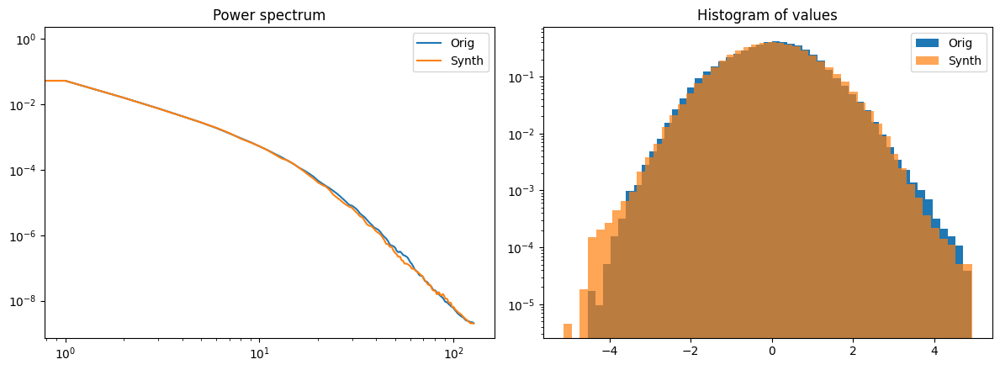

<Figure size 640x480 with 0 Axes>

Histogram
zfloor_two_phase_reg1e-4


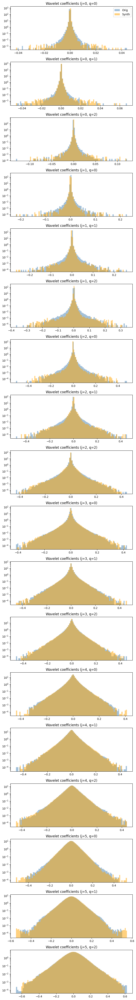

<Figure size 640x480 with 0 Axes>

Structure functions
zfloor_two_phase_reg1e-4
Computing structure functions for 127 lags...
Computing structure functions for 127 lags...


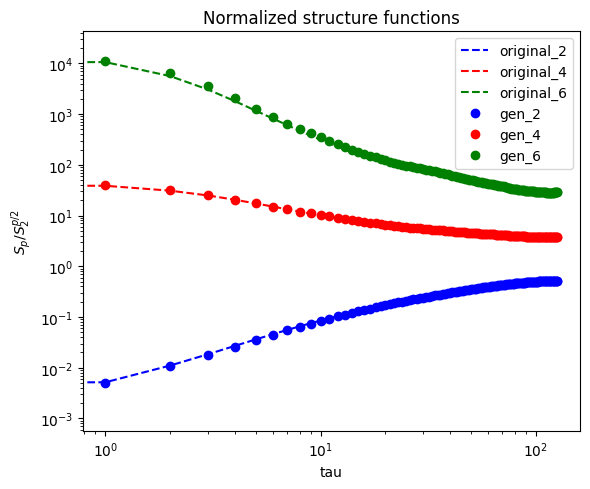

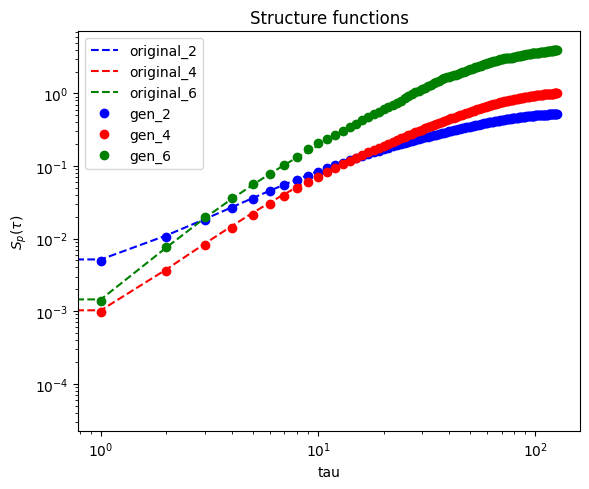

<Figure size 640x480 with 0 Axes>

In [23]:
%matplotlib inline 
def run_project_diagnostics(x_ref, result):
    """
    Uses the existing project plotting utilities. These functions usually create
    their own figures, so we call each diagnostic once per model and add titles.
    """
    diagnostic_functions = [
        ('Spectrum', spec_plot),
        ('Histogram', hist_plot),
        ('Structure functions', structure_plot),
    ]

    for diag_name, diag_fun in diagnostic_functions:
        print('' + '=' * 80)
        print(diag_name)
        print('=' * 80)
        print(label)
        diag_fun(x_ref, result['xt'])
        plt.suptitle(f"{diag_name}: {label}")
        plt.show()

    #print('' + '=' * 80)
    #print('Cross statistics')
    #print('=' * 80)
    #for key, exp in experiments.items():
        #print(exp['label'])
        #cross_plot(x_ref, xt_cg, pq=[(3, 1), (3, 3), (4, 4)])
        #plt.suptitle(f"Cross statistics: {exp['label']}")
        #plt.show()

run_project_diagnostics(x1, result)


## Entropy bound comparison

## Project entropy plotting utility for each model

## Plots for paper 

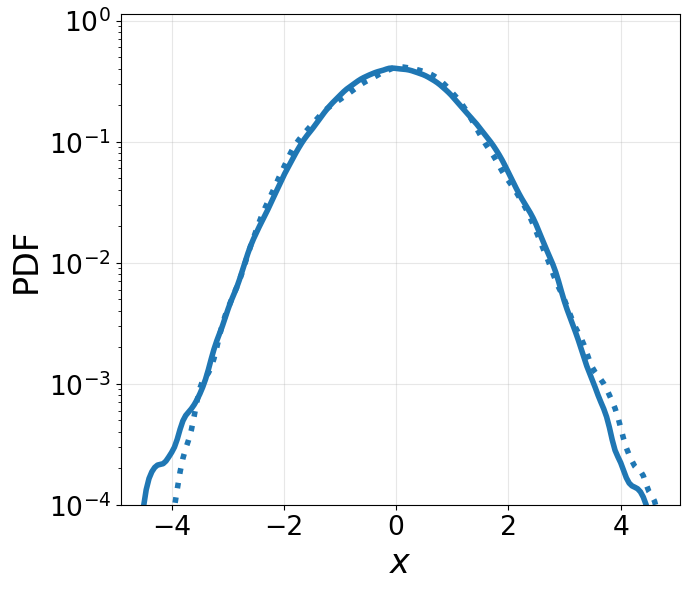

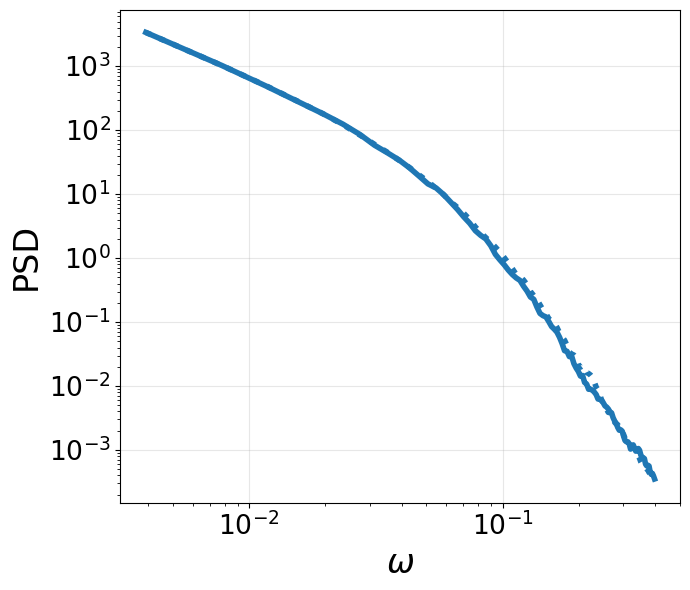

Computing structure functions for 127 lags...
Computing structure functions for 127 lags...


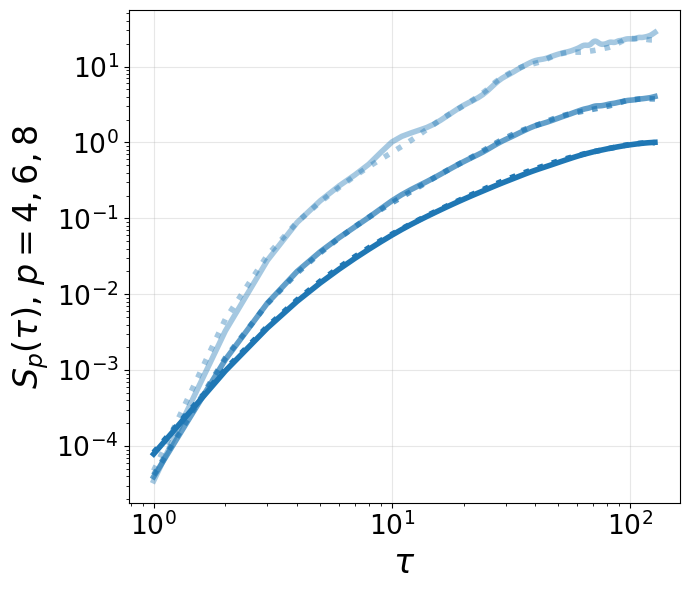

Loaded structure functions from cache!
Loaded structure functions from cache!


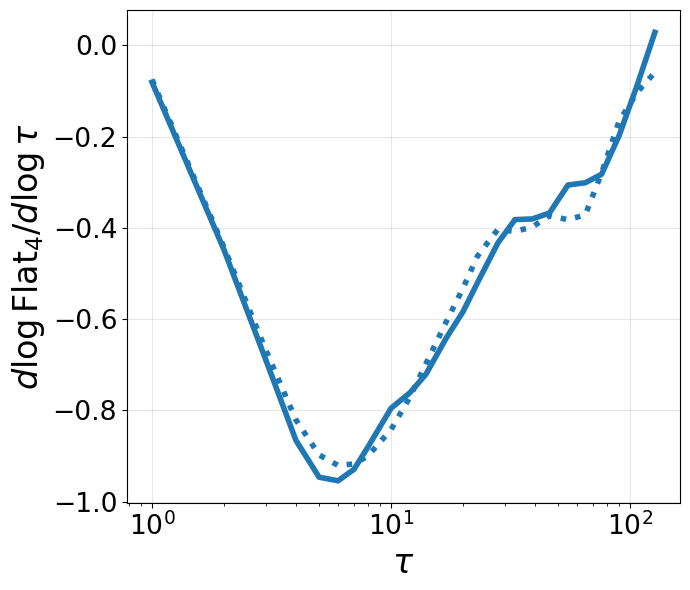

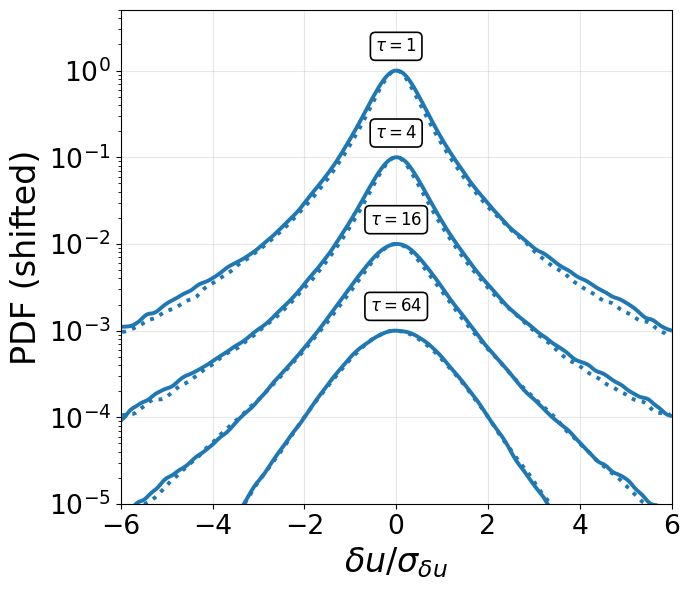

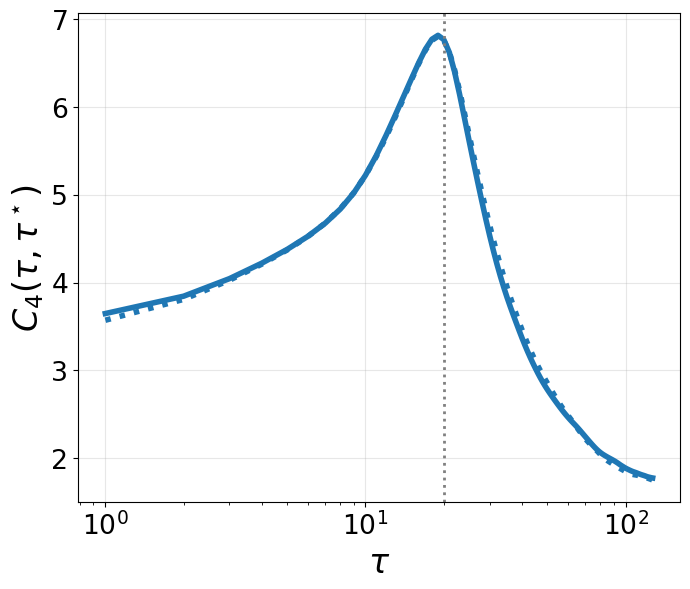

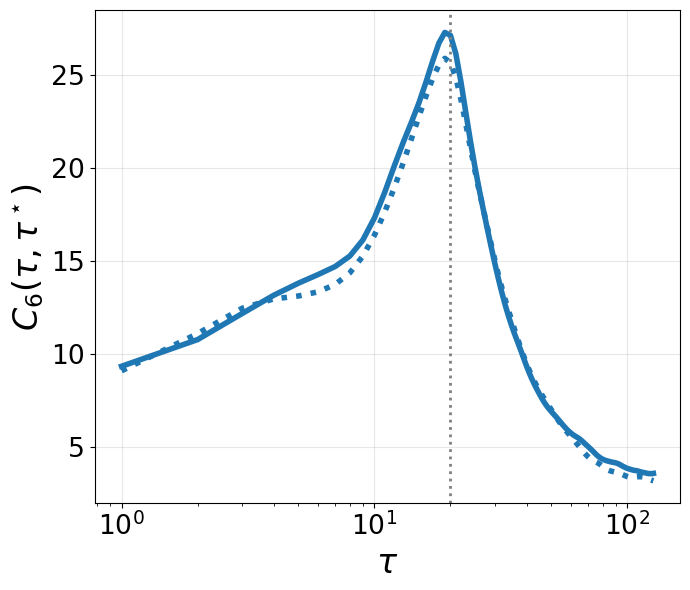

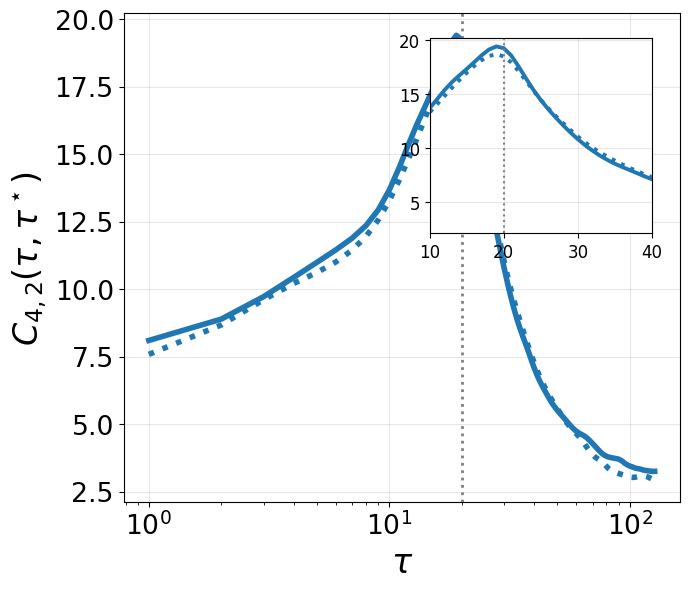

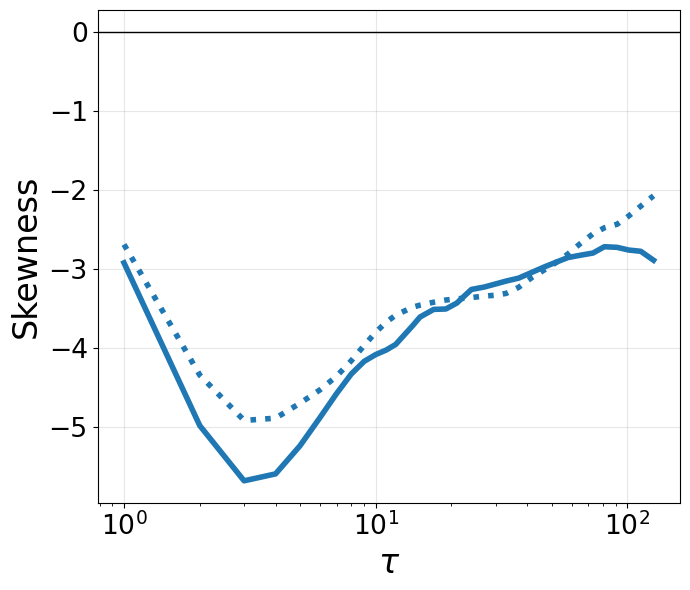

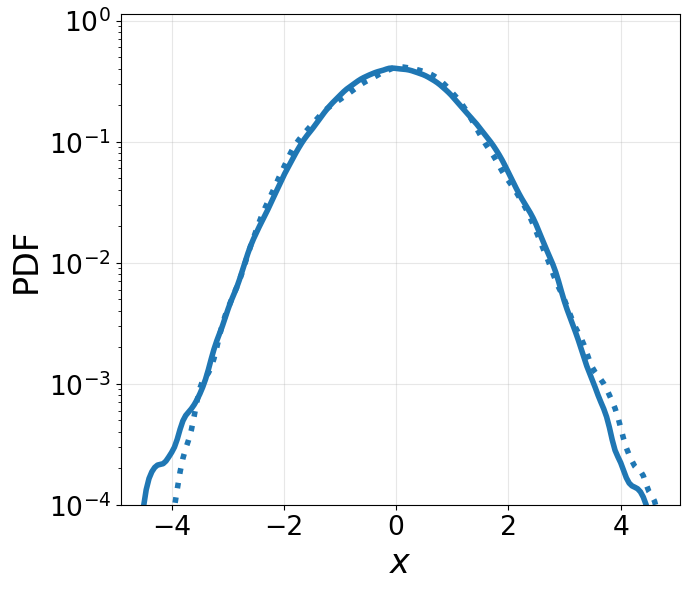

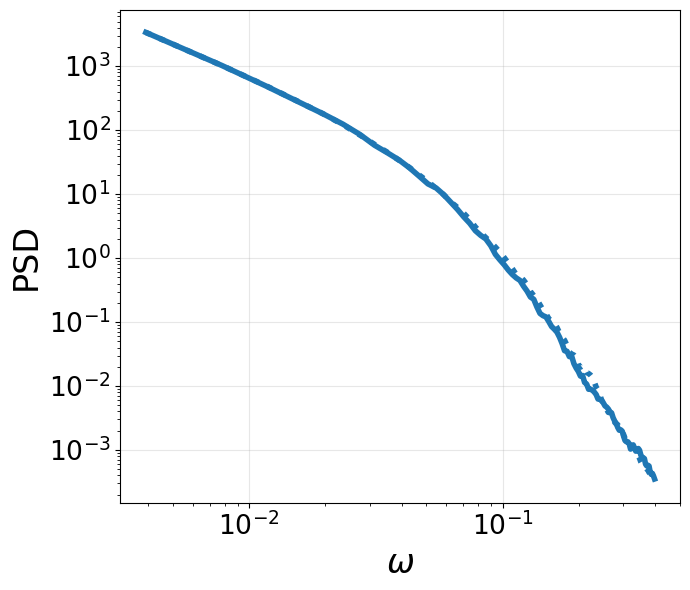

Loaded structure functions from cache!
Loaded structure functions from cache!


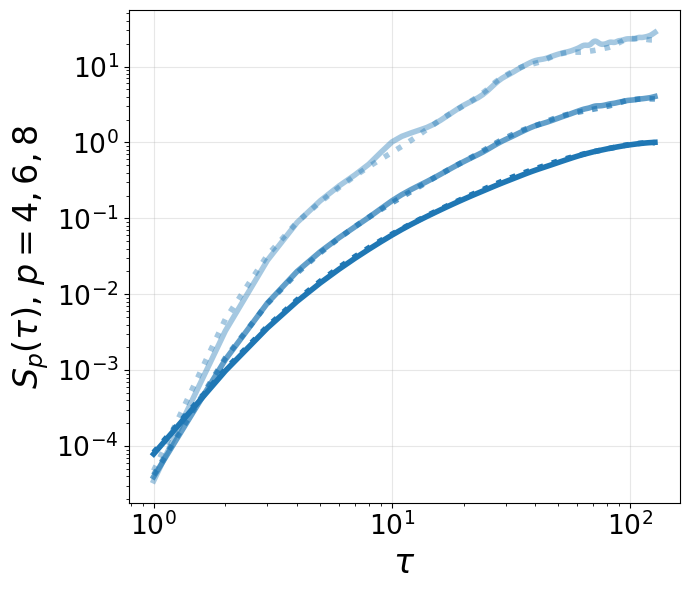

Loaded structure functions from cache!
Loaded structure functions from cache!


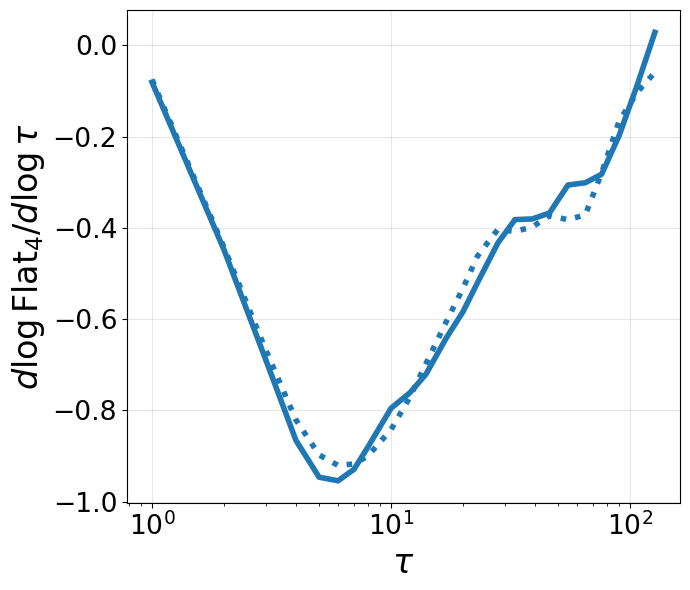

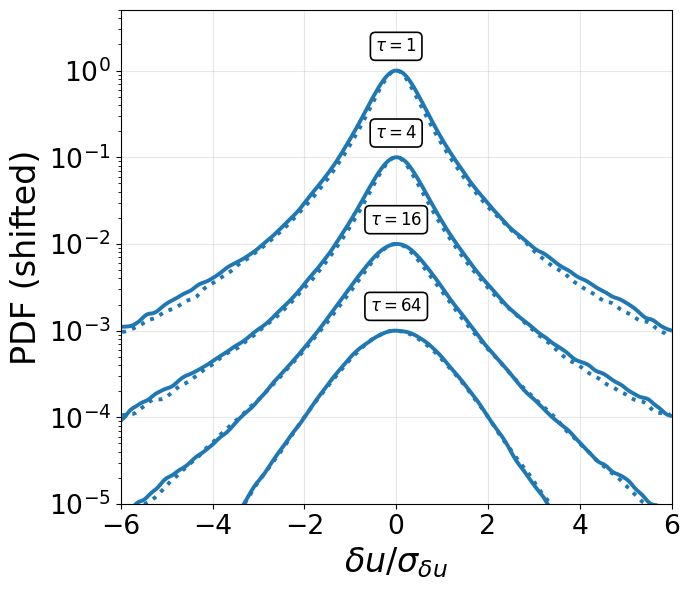

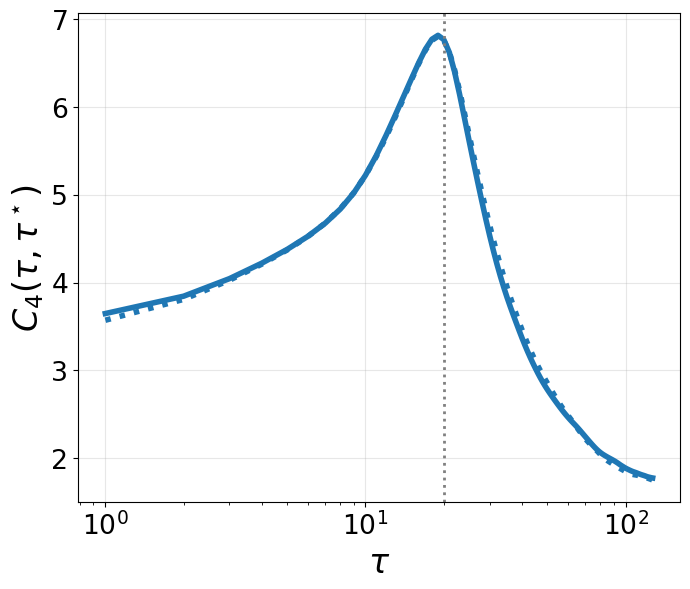

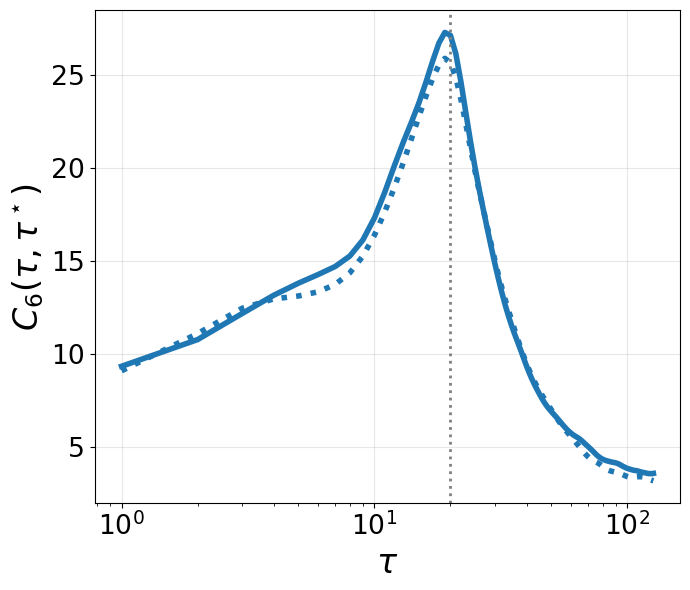

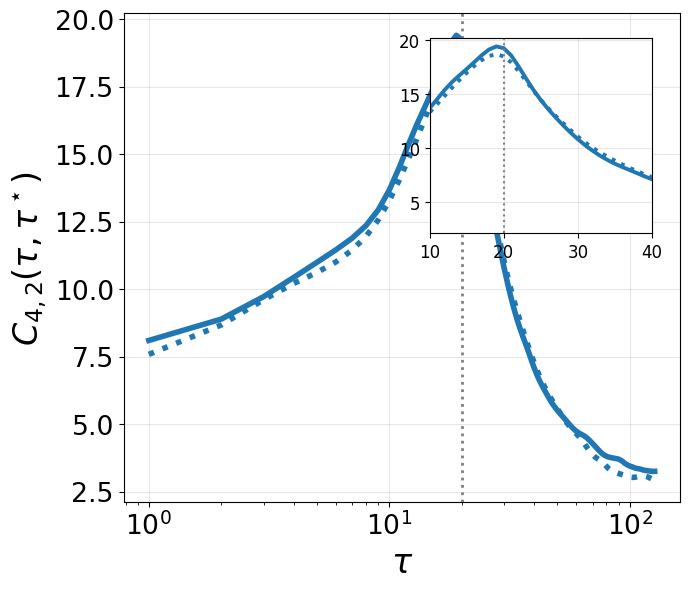

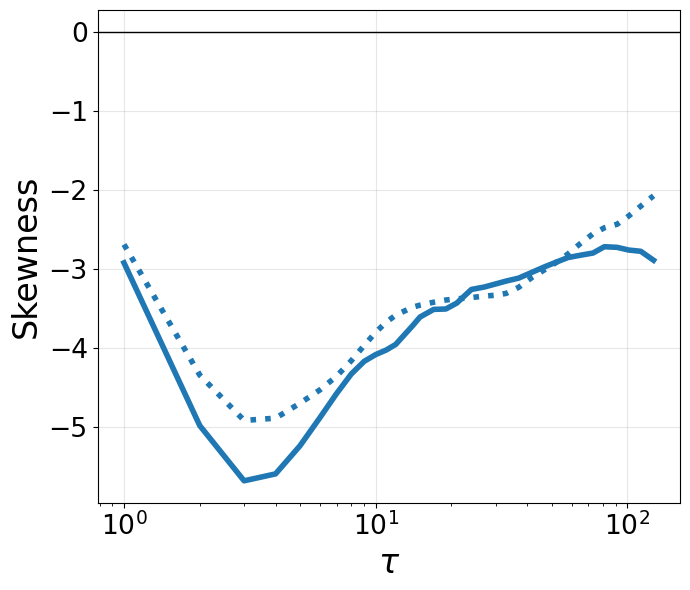

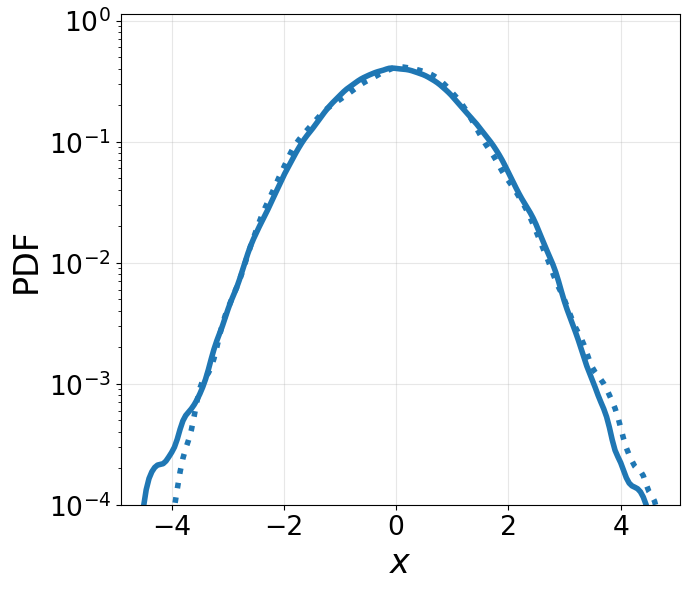

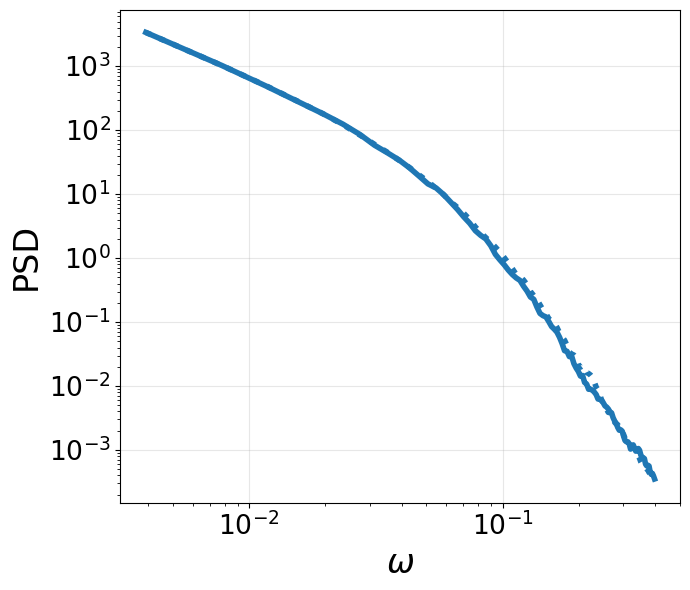

Loaded structure functions from cache!
Loaded structure functions from cache!


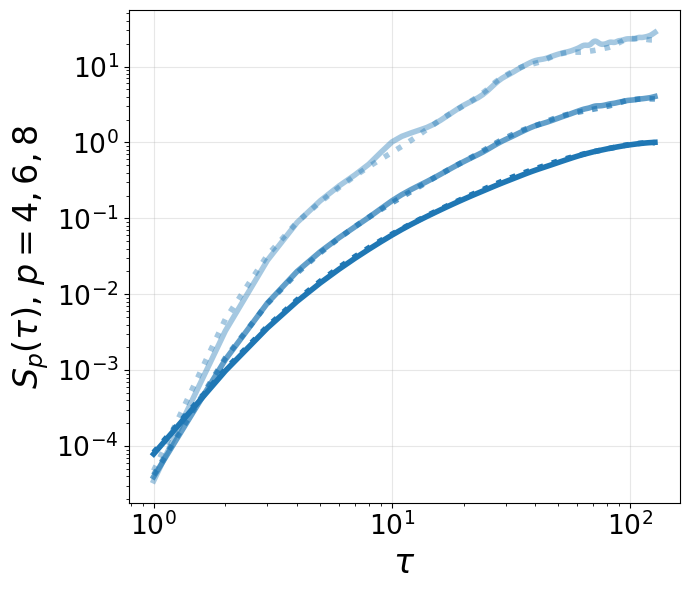

Loaded structure functions from cache!
Loaded structure functions from cache!


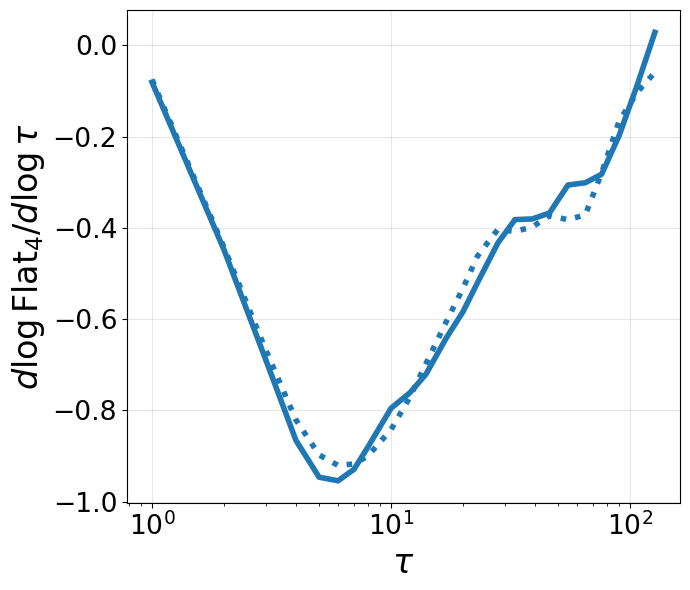

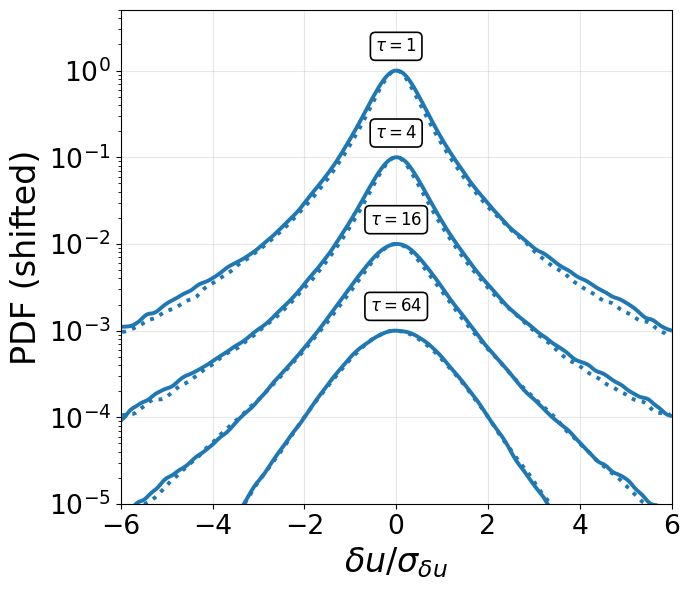

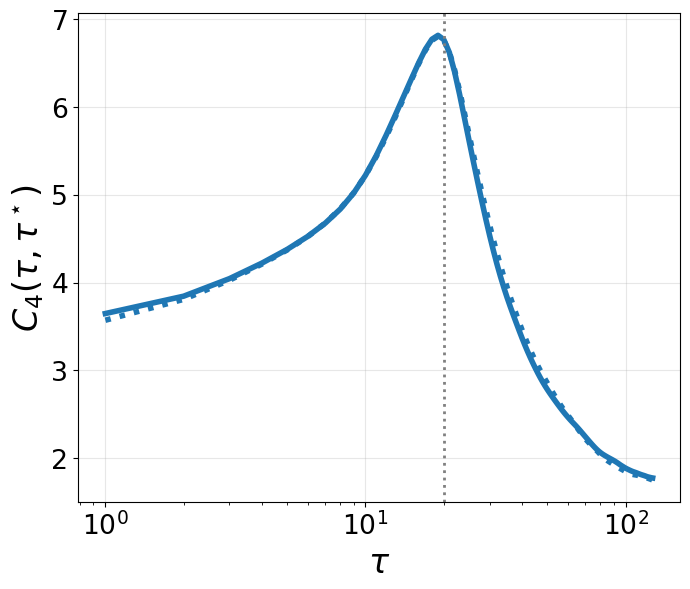

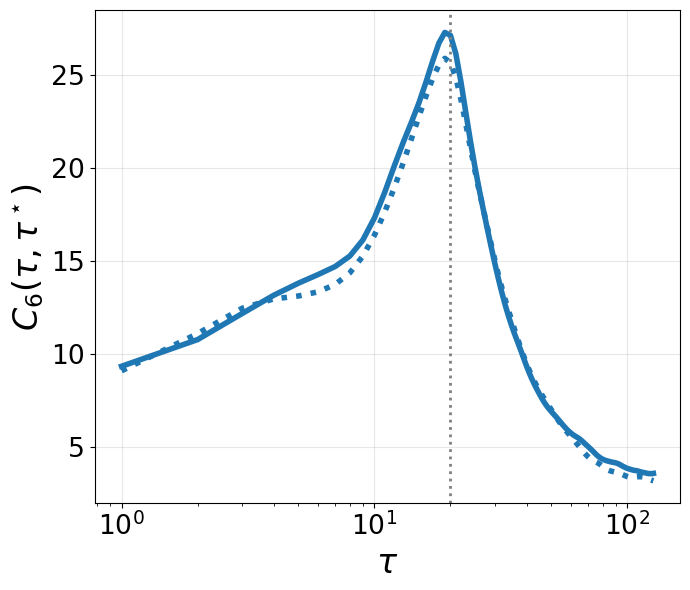

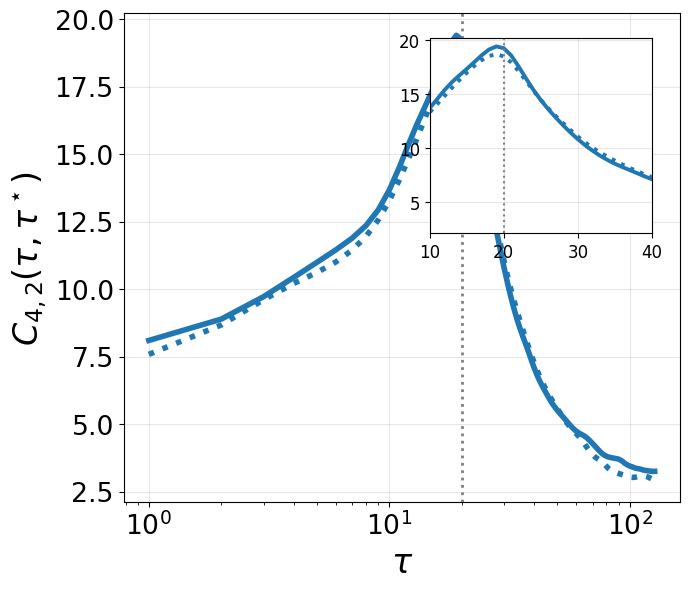

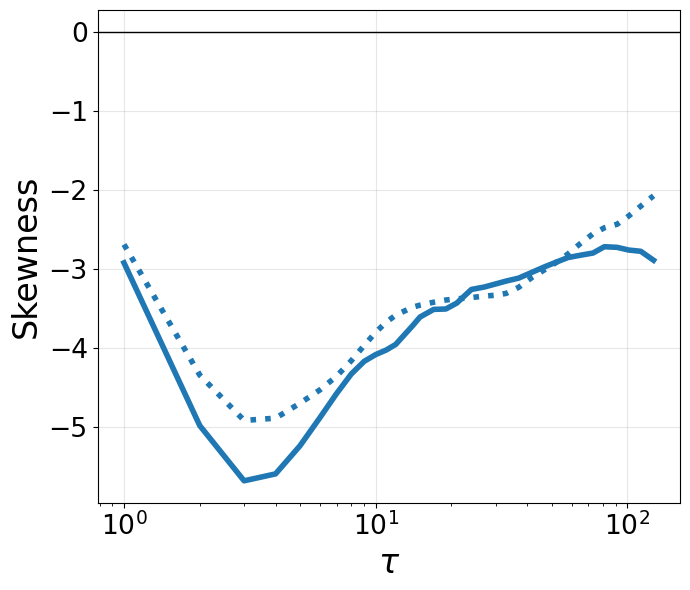

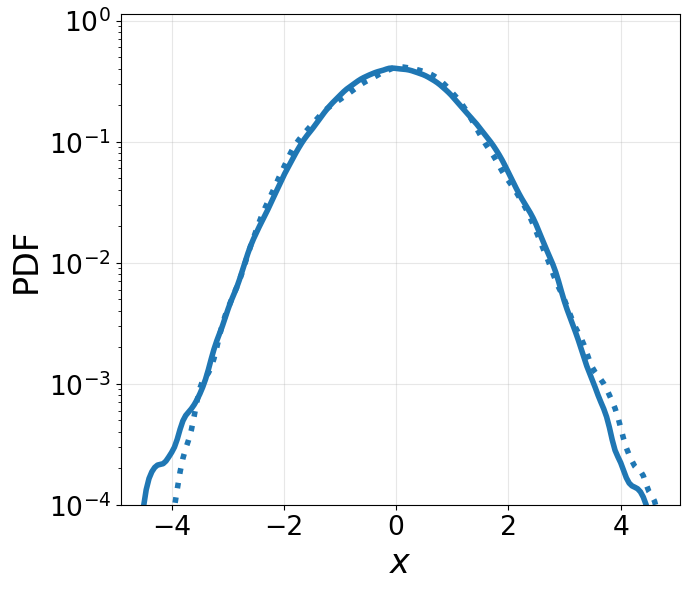

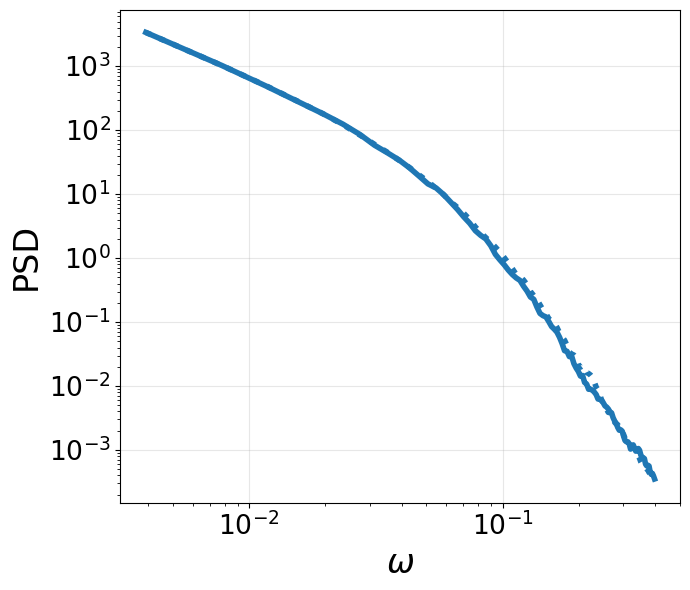

Loaded structure functions from cache!
Loaded structure functions from cache!


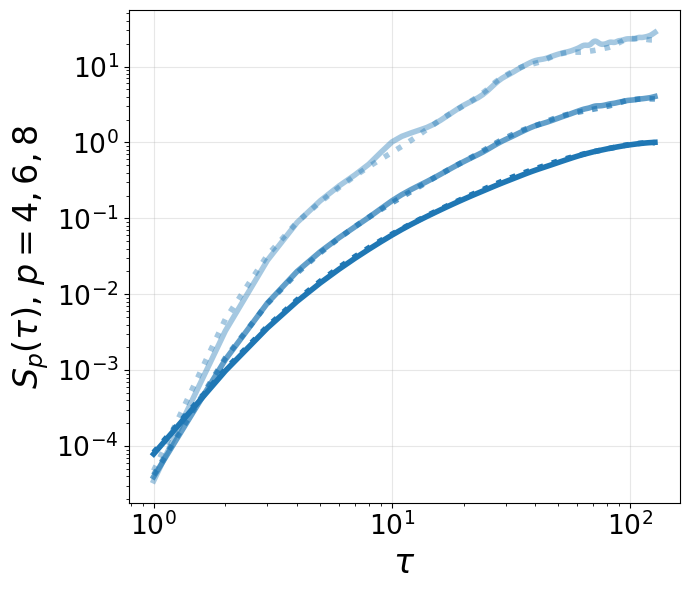

Loaded structure functions from cache!
Loaded structure functions from cache!


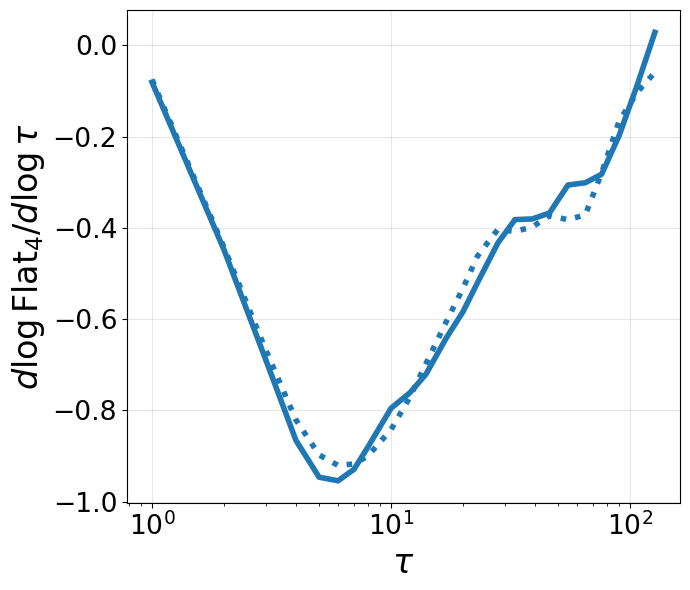

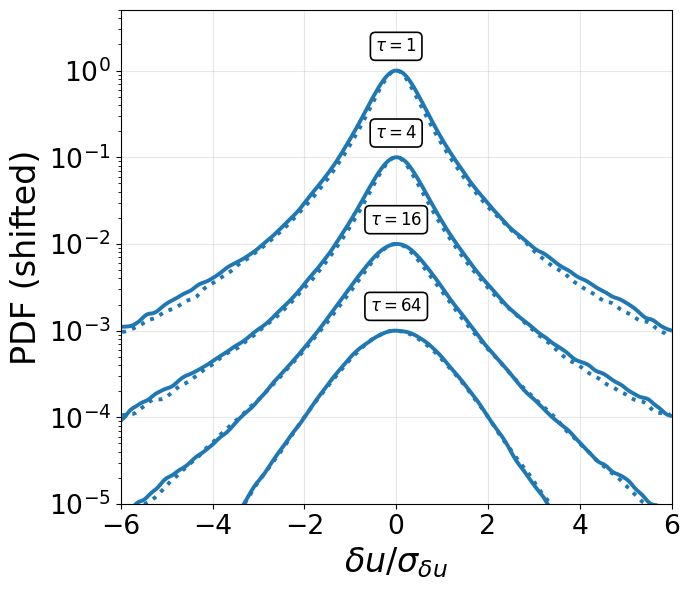

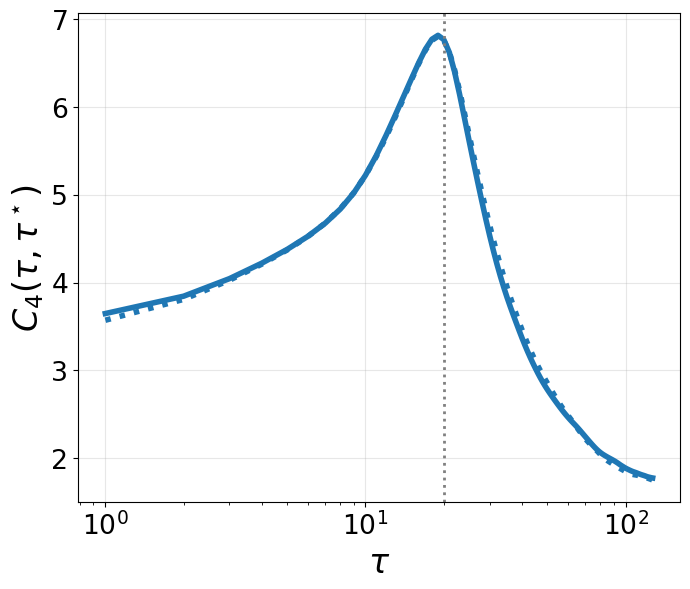

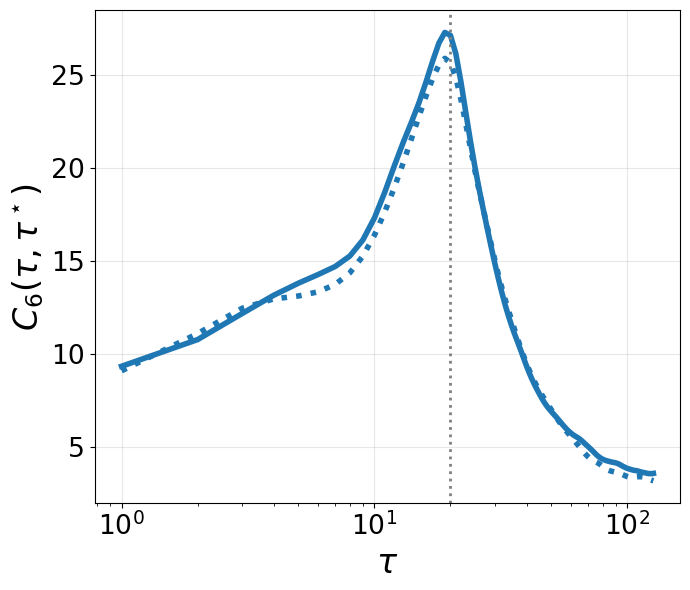

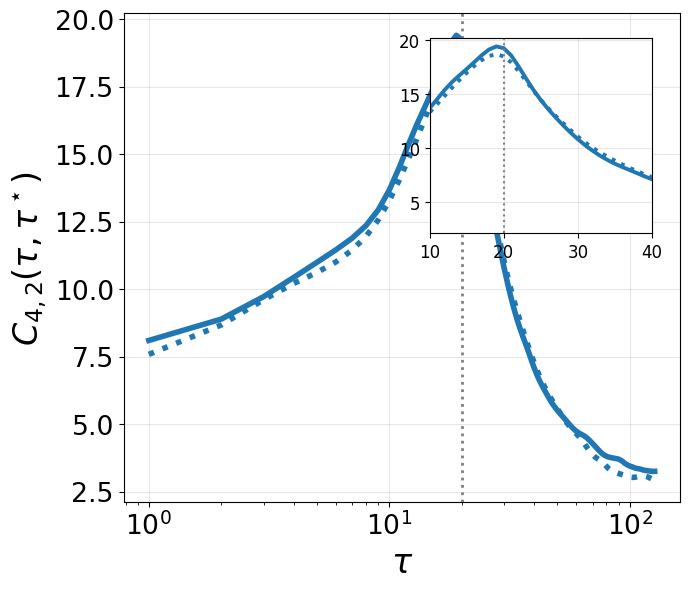

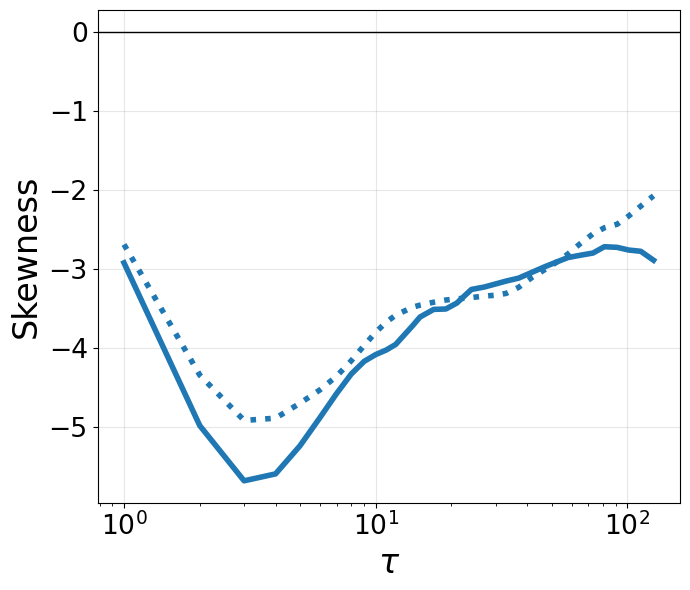

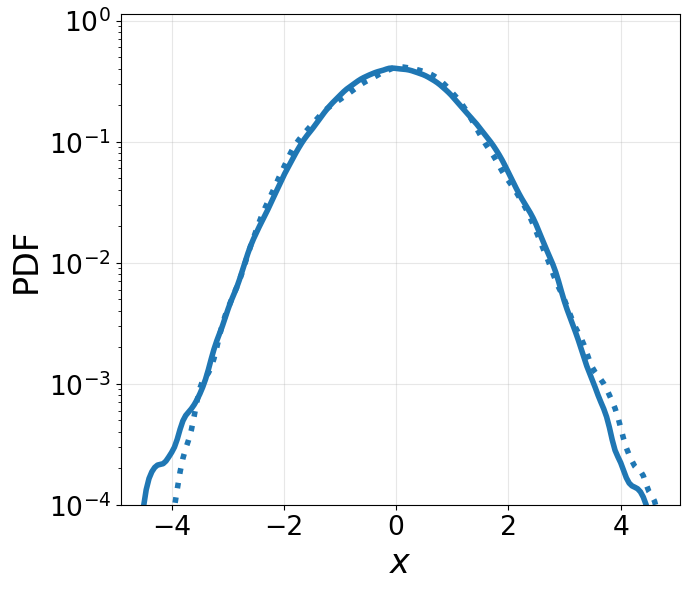

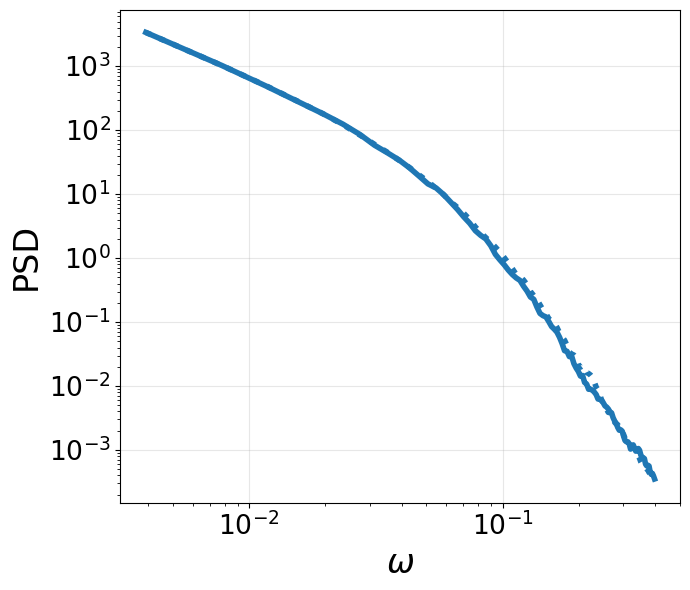

Loaded structure functions from cache!
Loaded structure functions from cache!


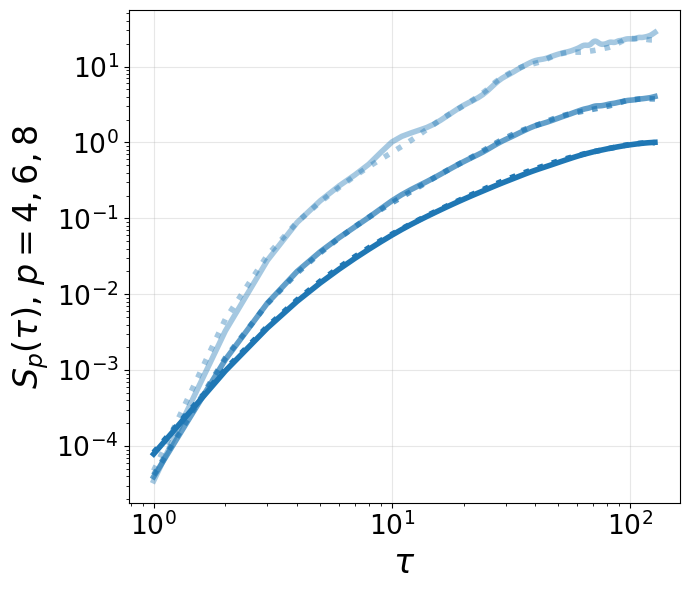

Loaded structure functions from cache!
Loaded structure functions from cache!


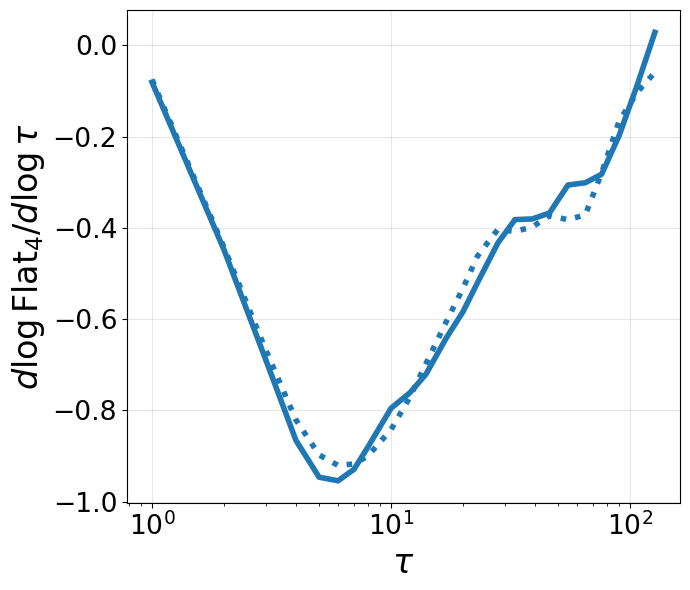

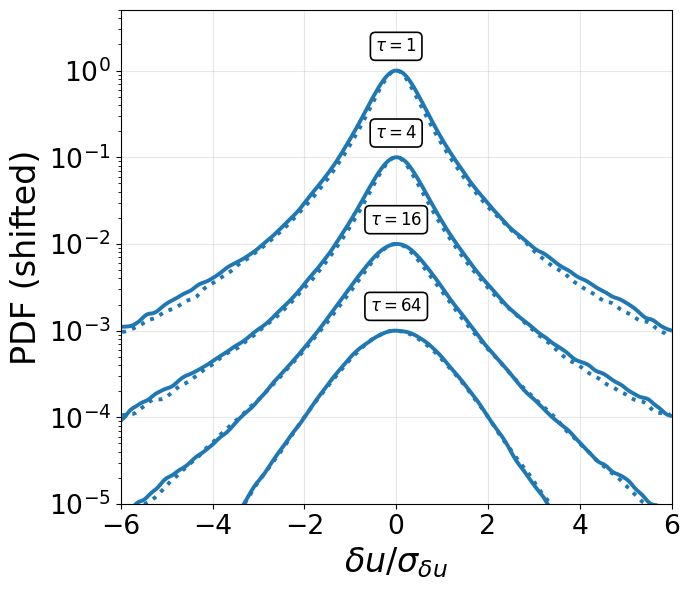

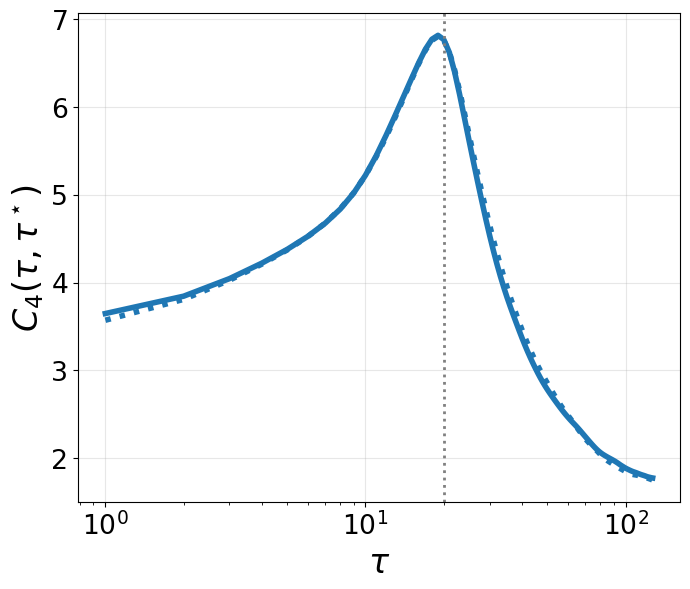

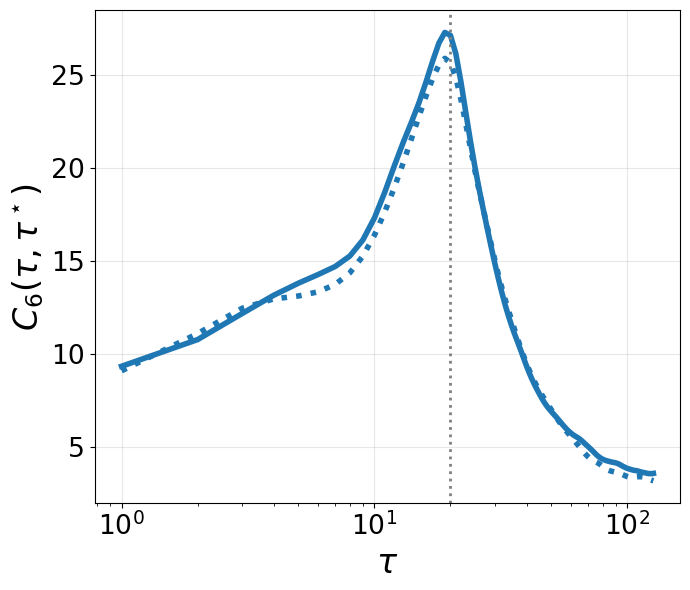

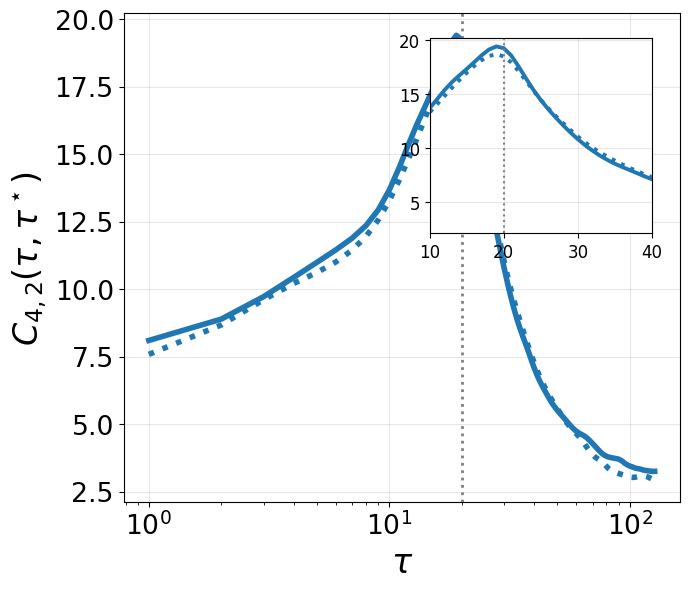

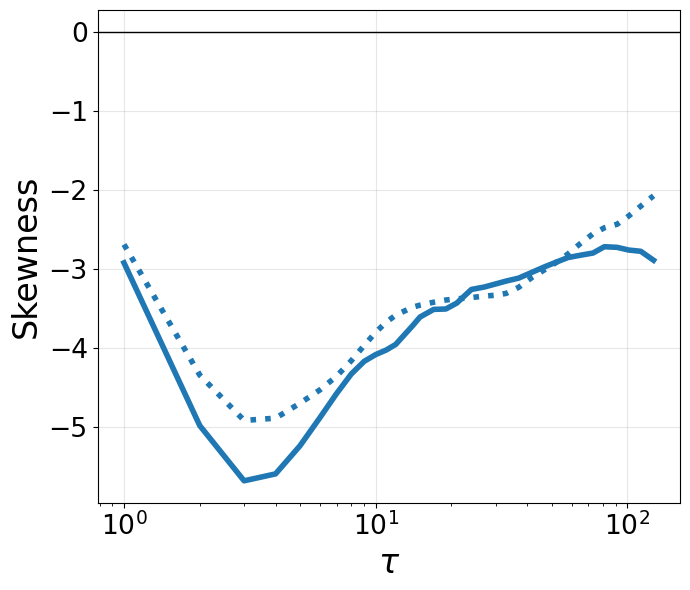

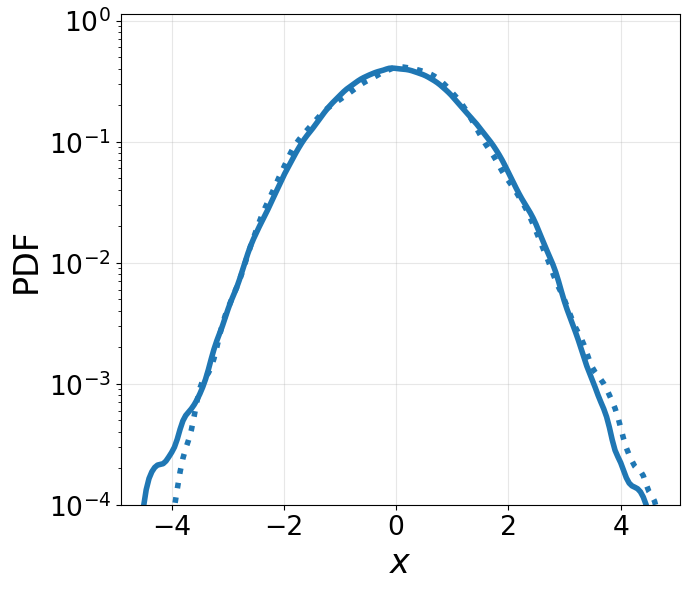

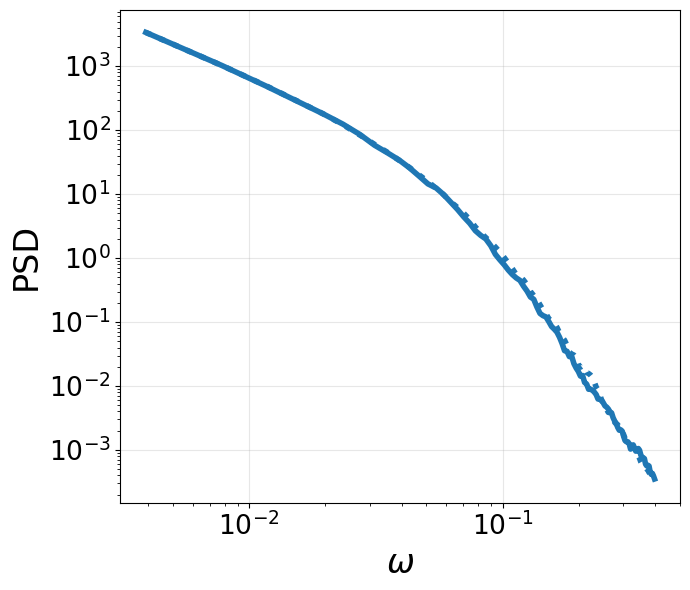

Loaded structure functions from cache!
Loaded structure functions from cache!


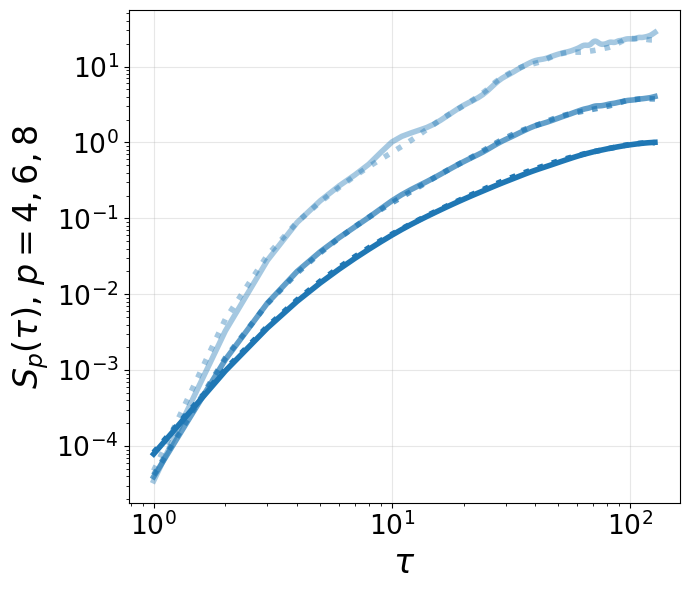

Loaded structure functions from cache!
Loaded structure functions from cache!


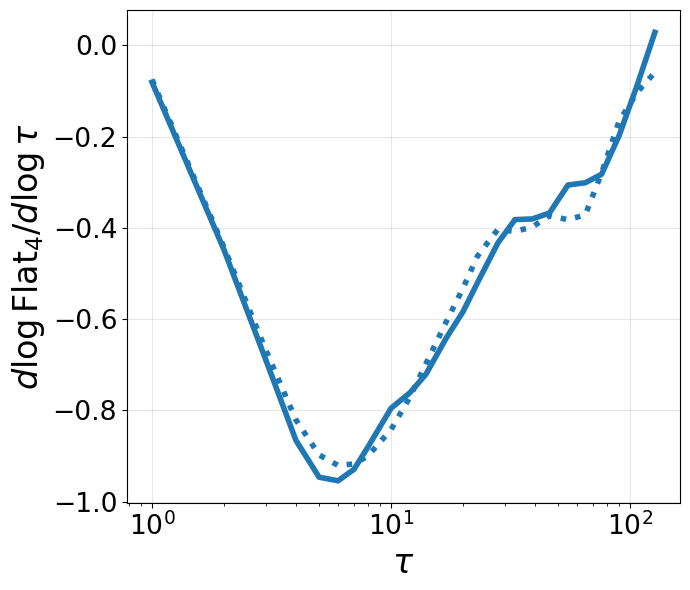

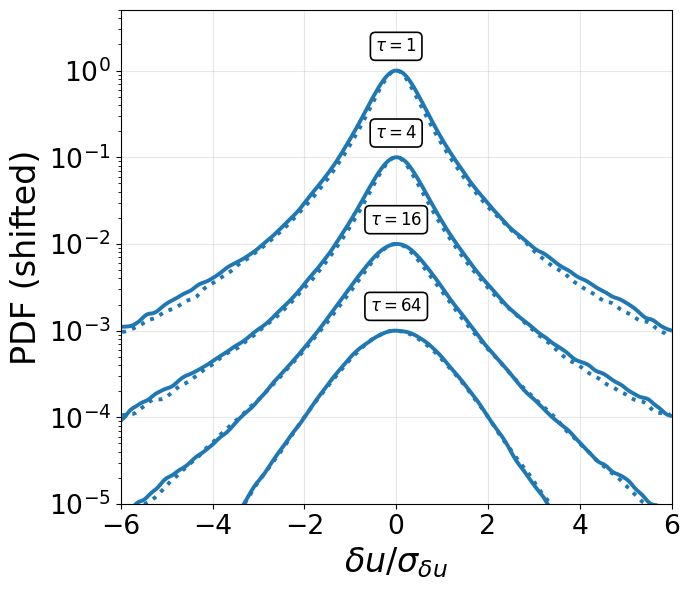

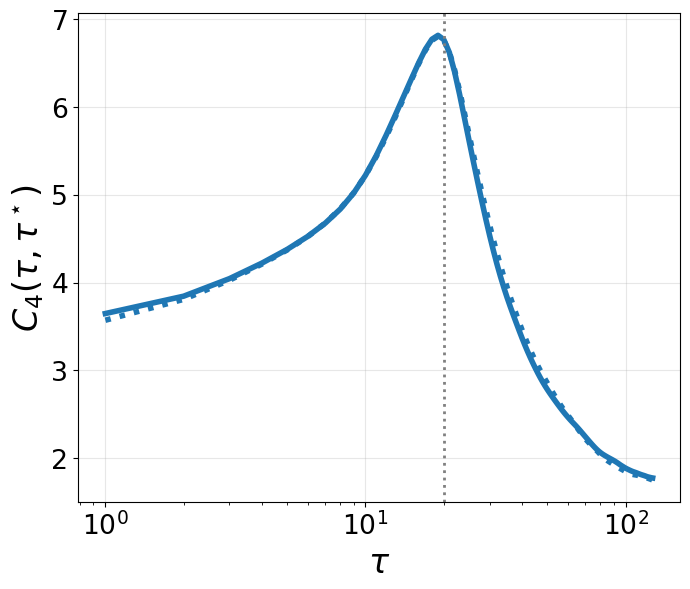

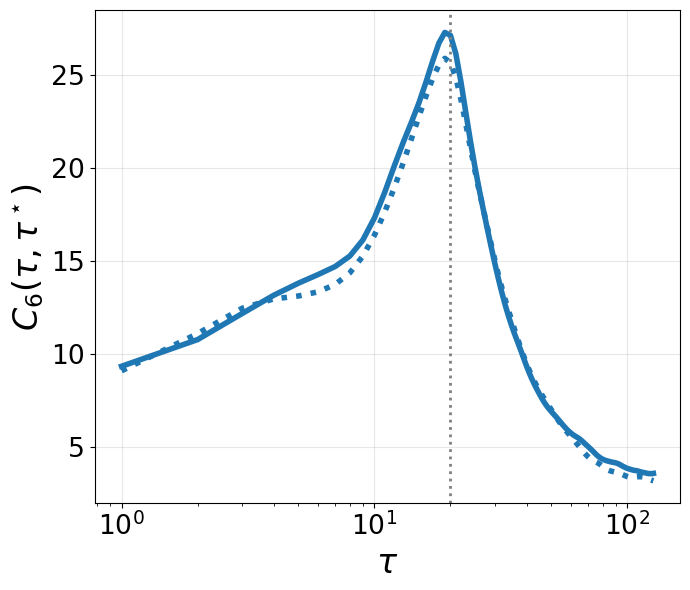

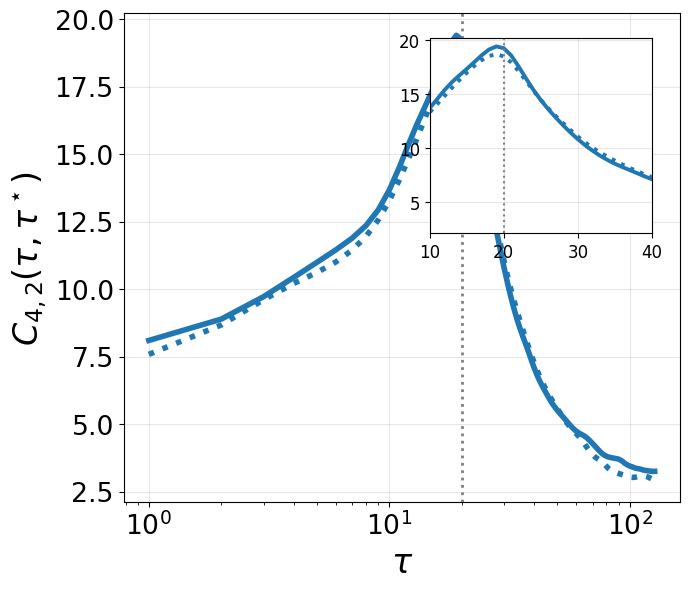

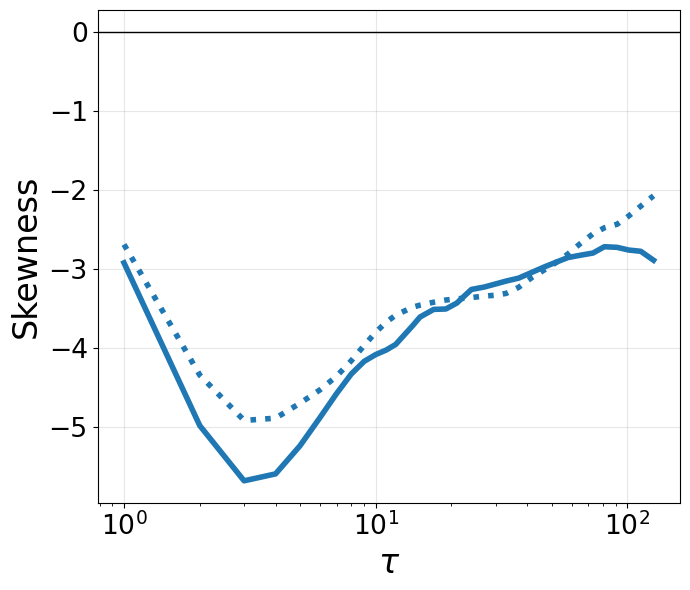

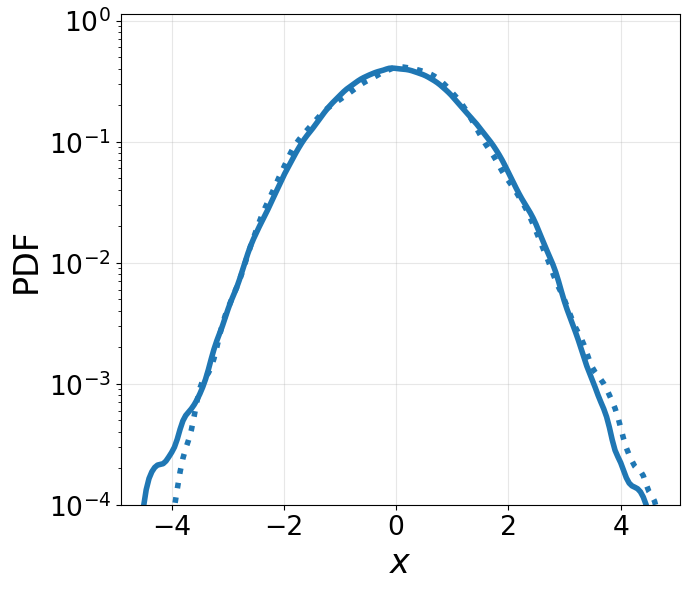

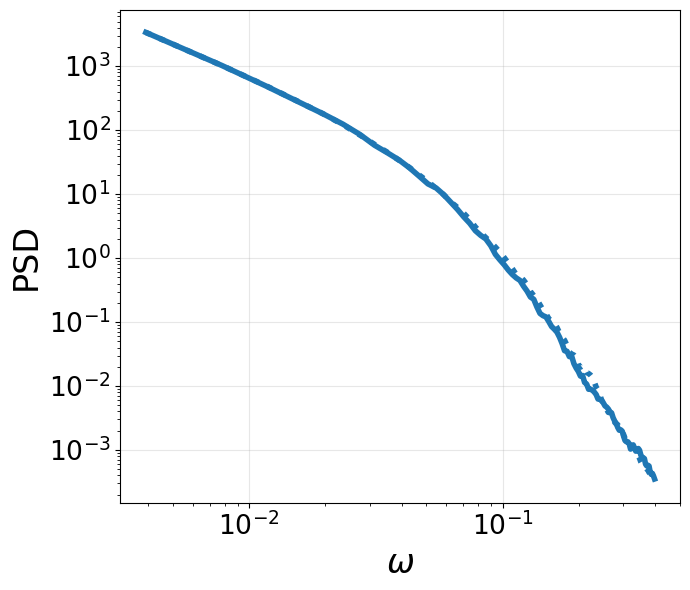

Loaded structure functions from cache!
Loaded structure functions from cache!


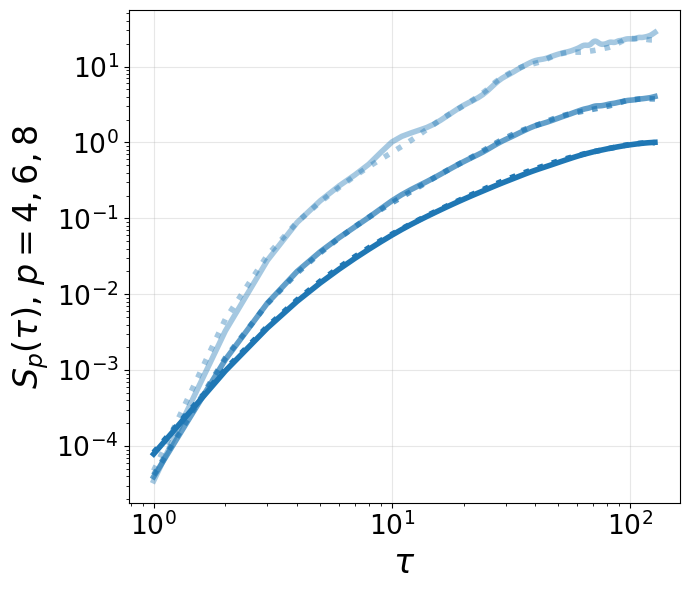

Loaded structure functions from cache!
Loaded structure functions from cache!


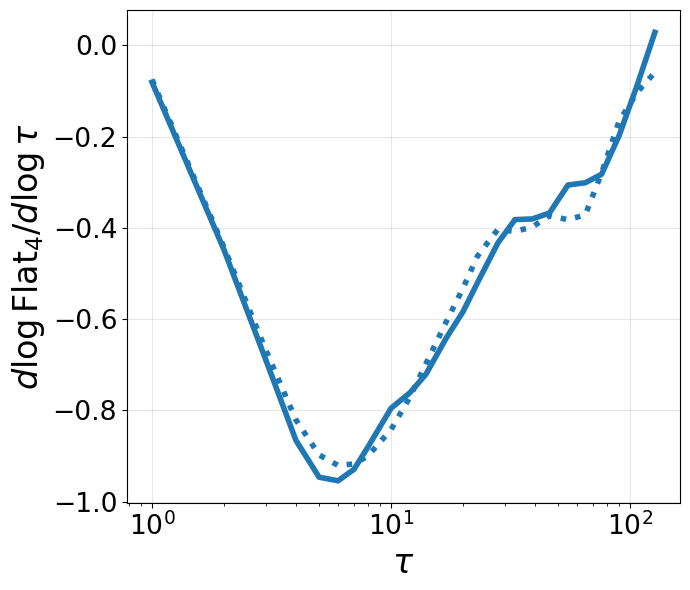

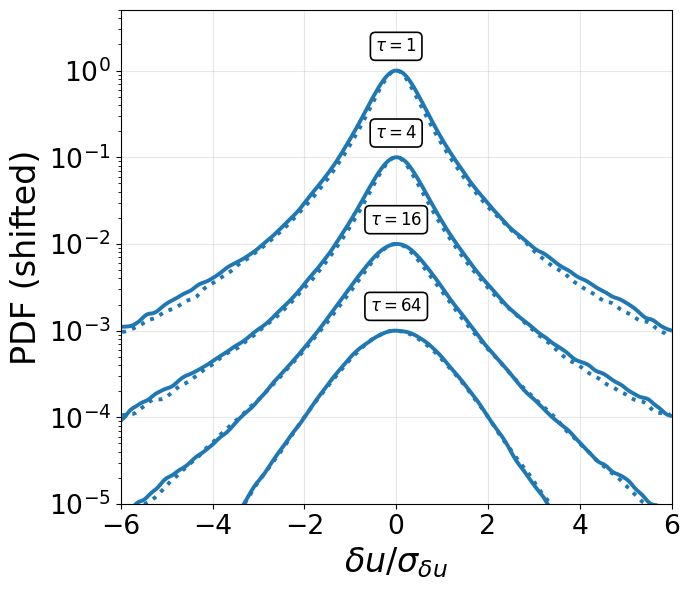

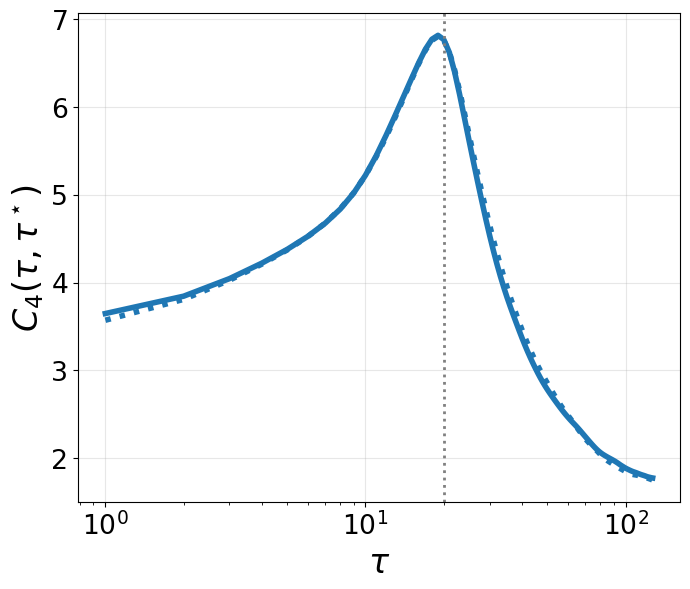

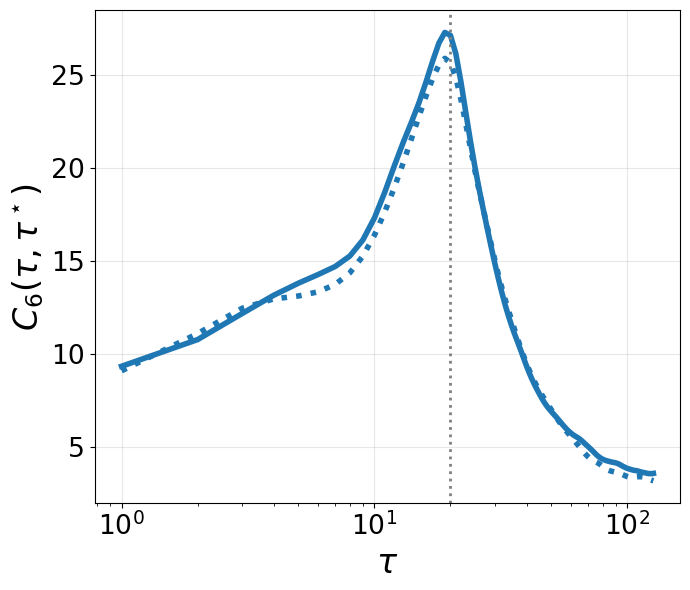

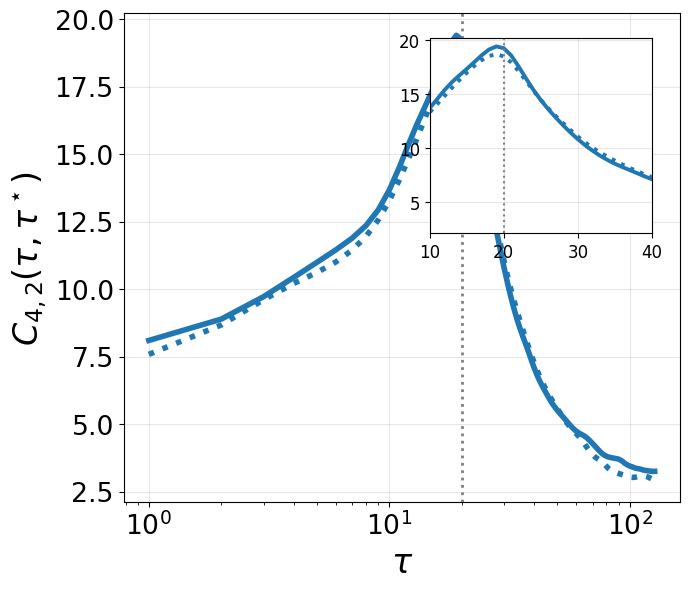

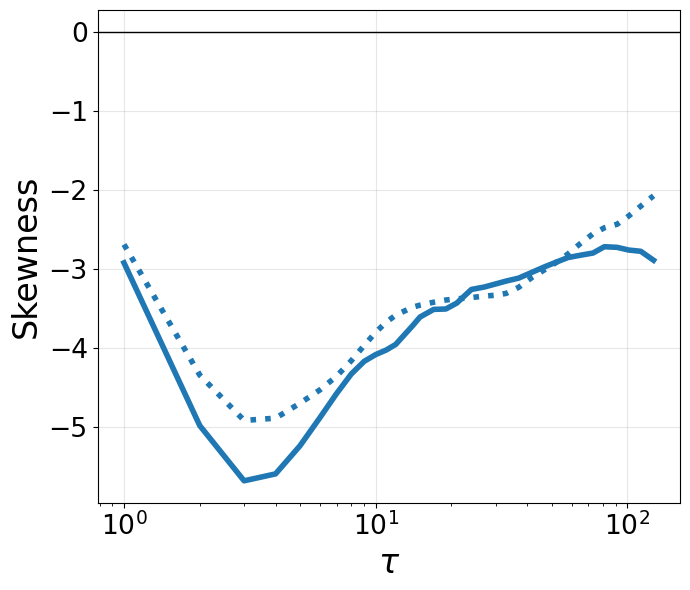

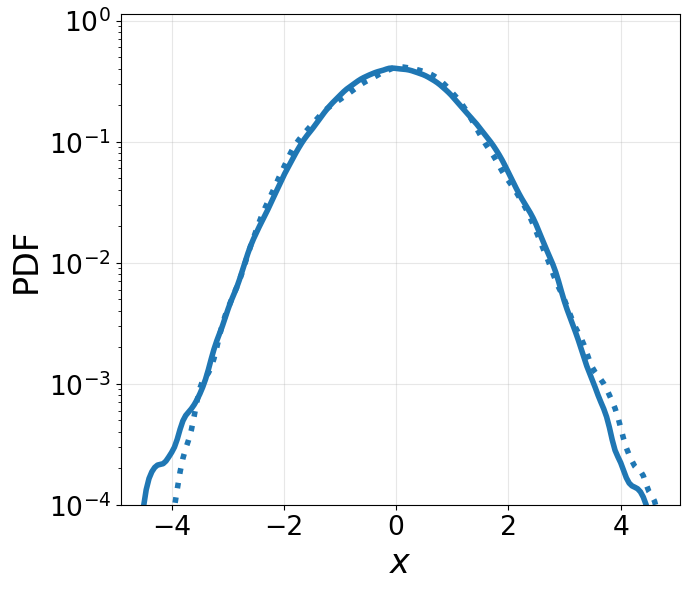

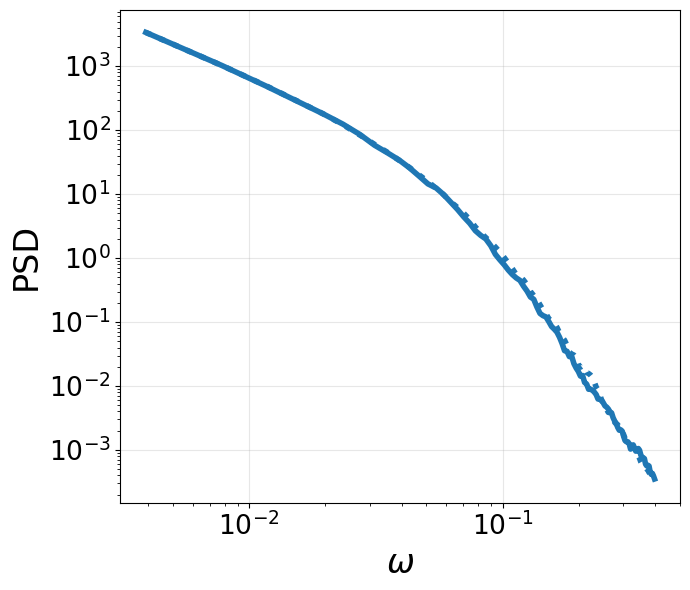

Loaded structure functions from cache!
Loaded structure functions from cache!


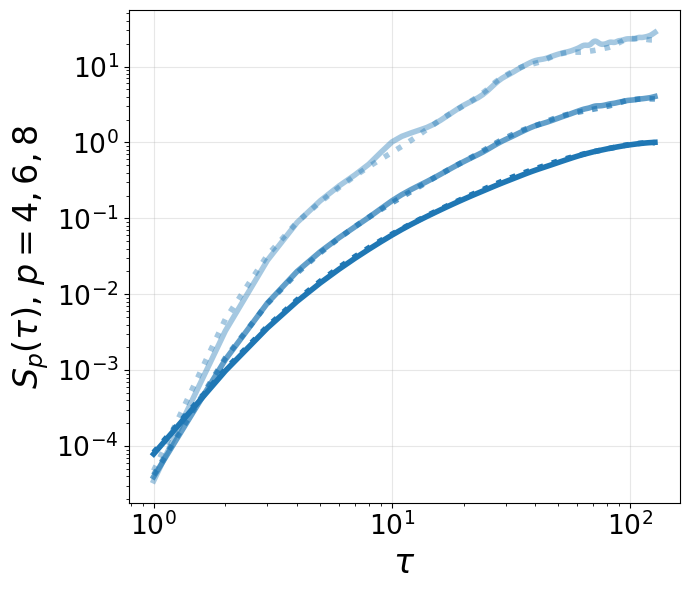

Loaded structure functions from cache!
Loaded structure functions from cache!


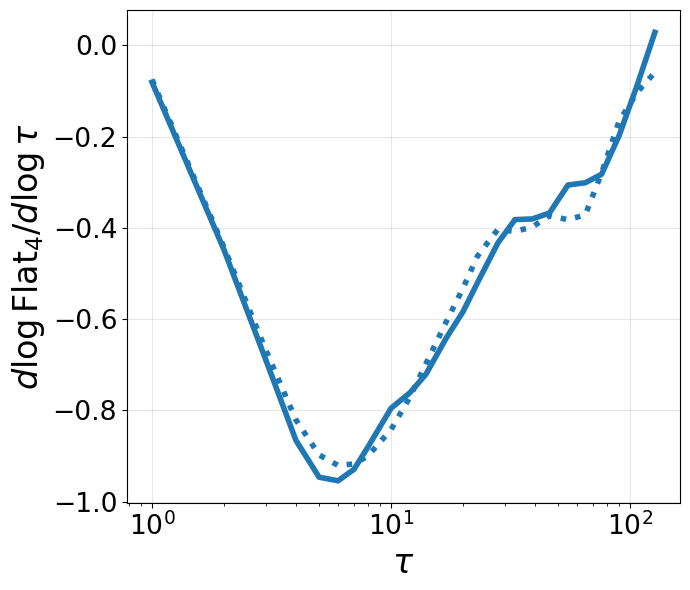

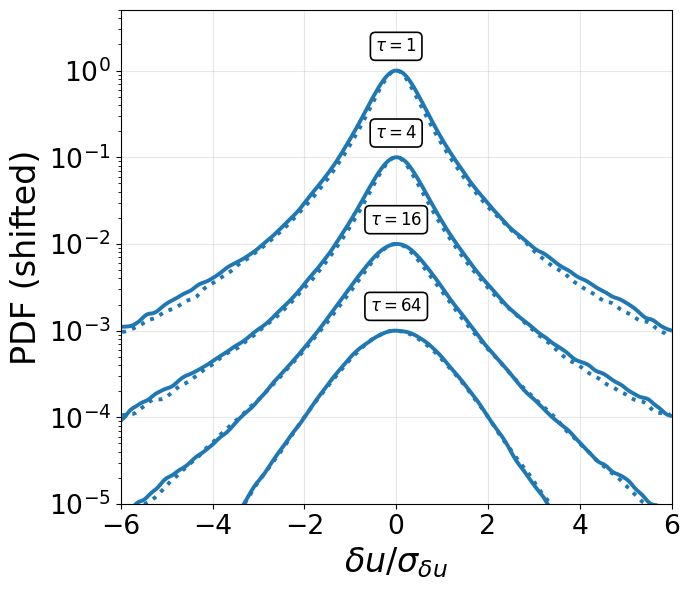

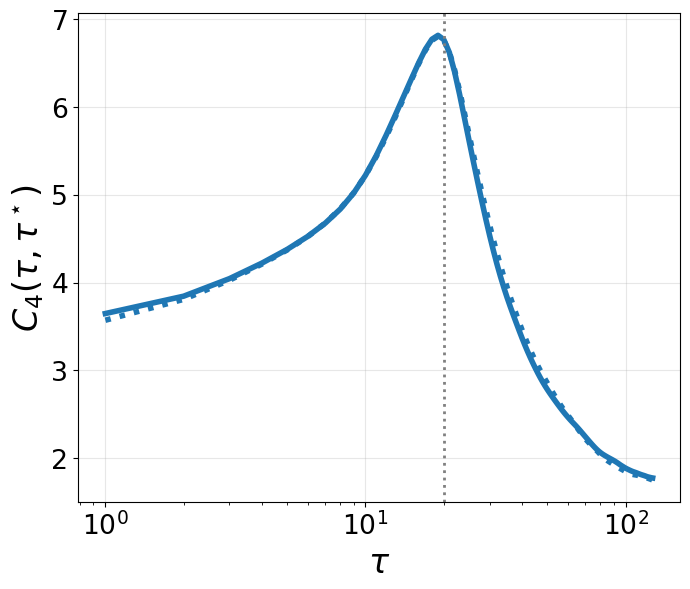

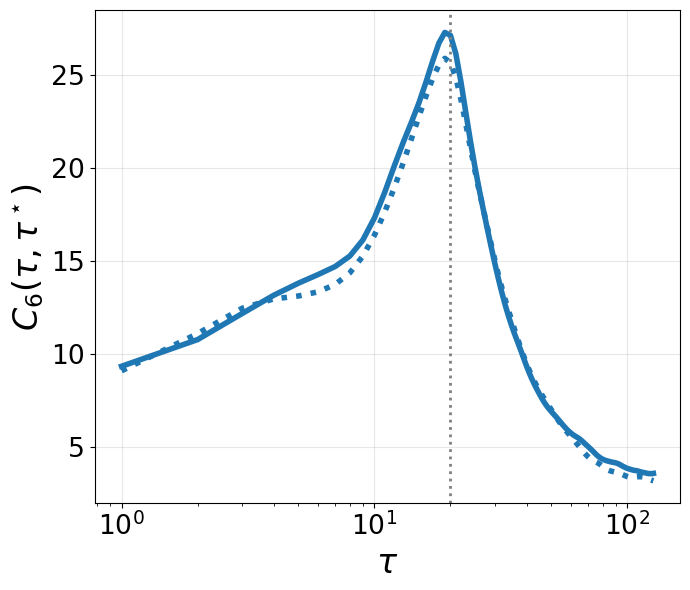

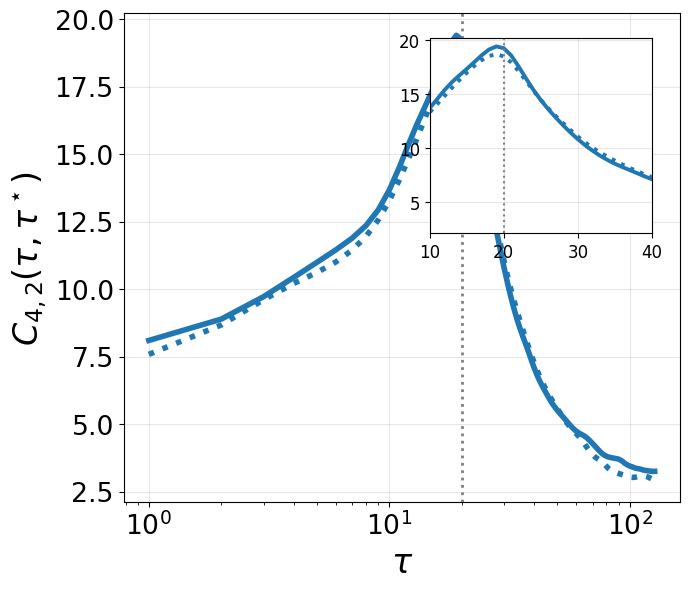

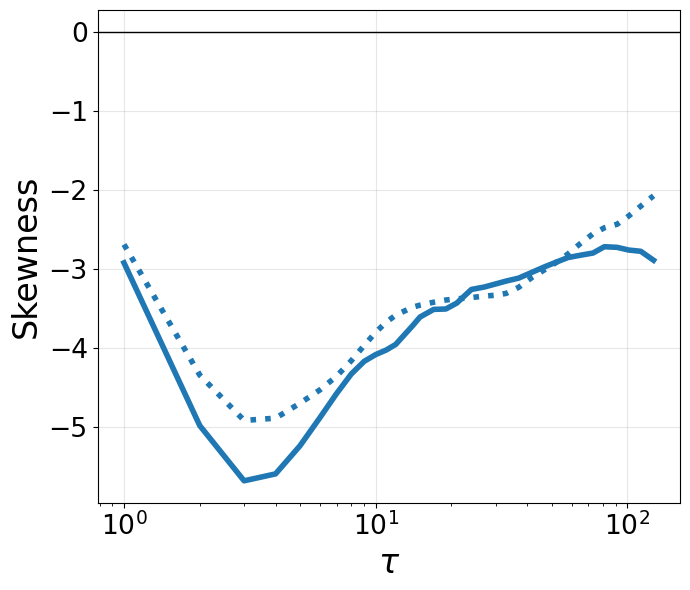

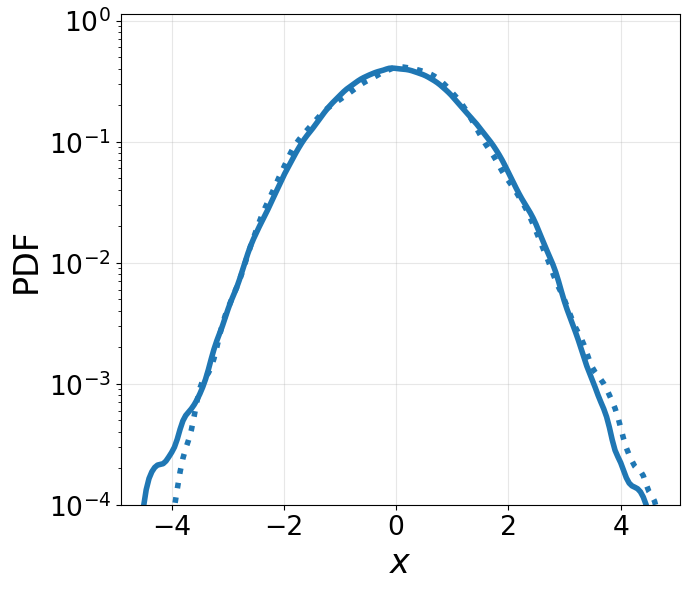

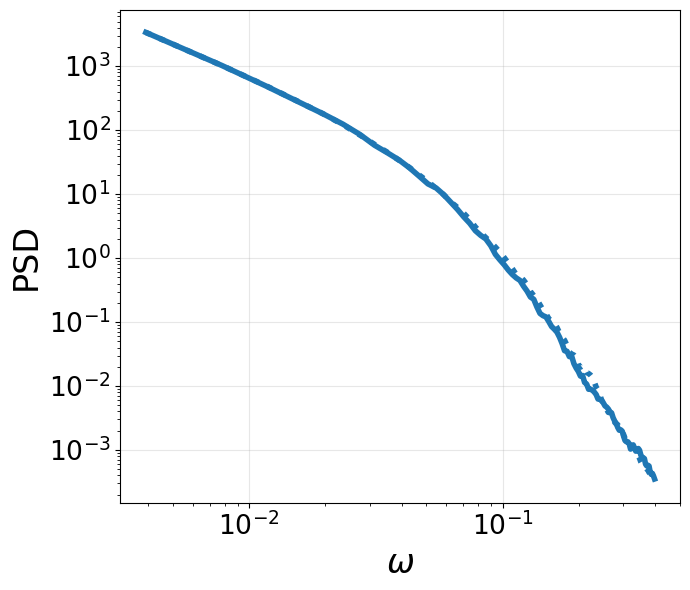

Loaded structure functions from cache!
Loaded structure functions from cache!


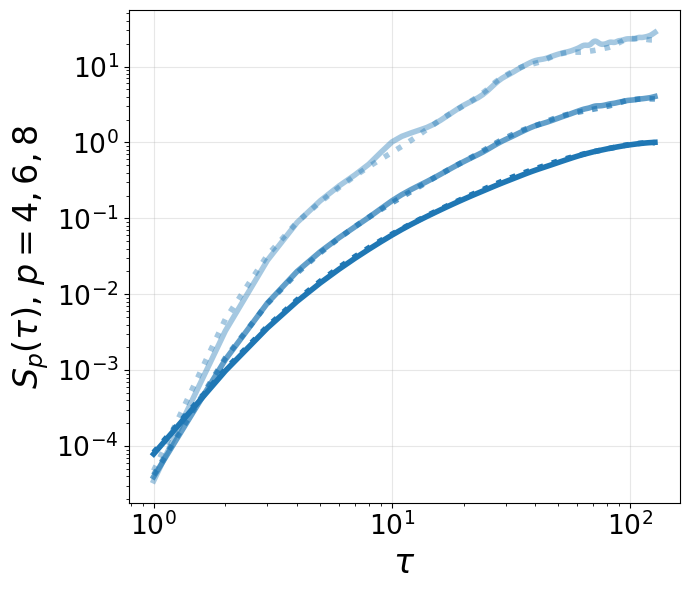

Loaded structure functions from cache!
Loaded structure functions from cache!


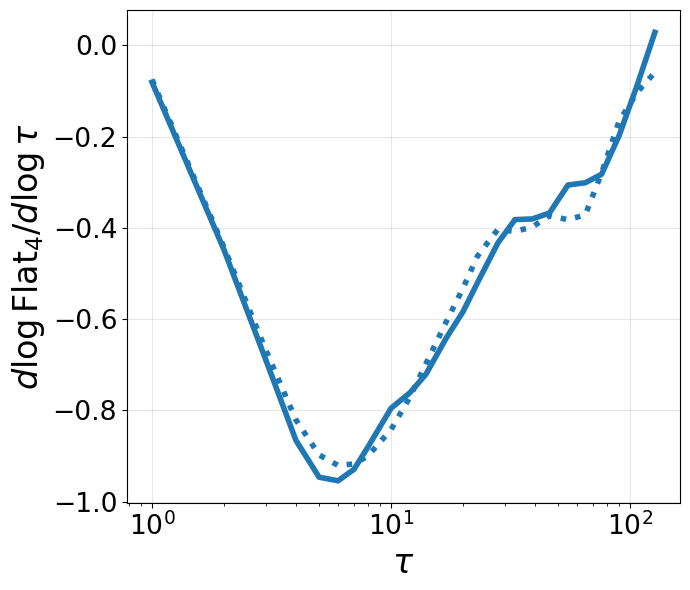

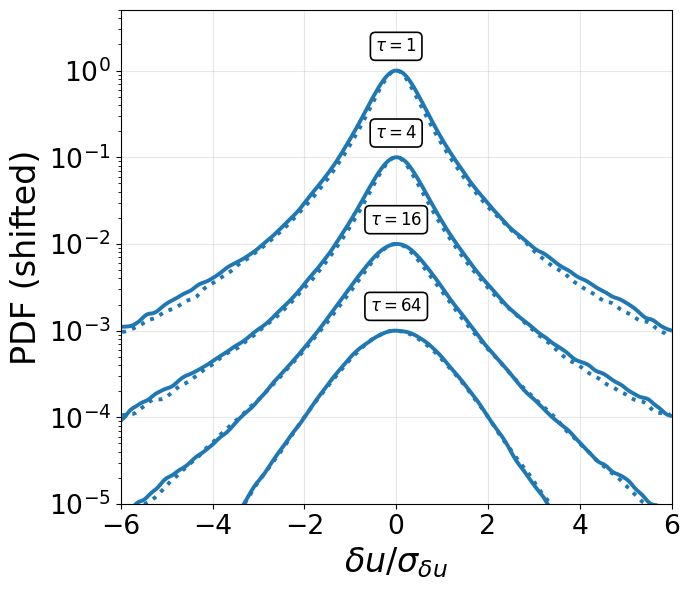

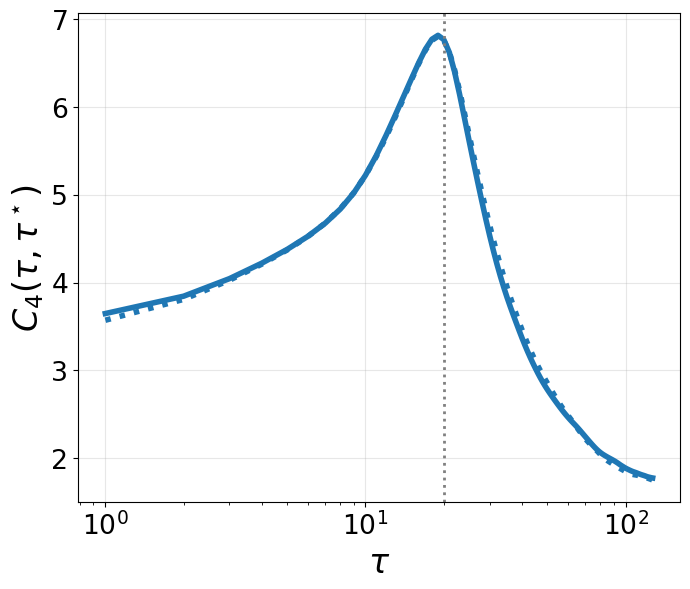

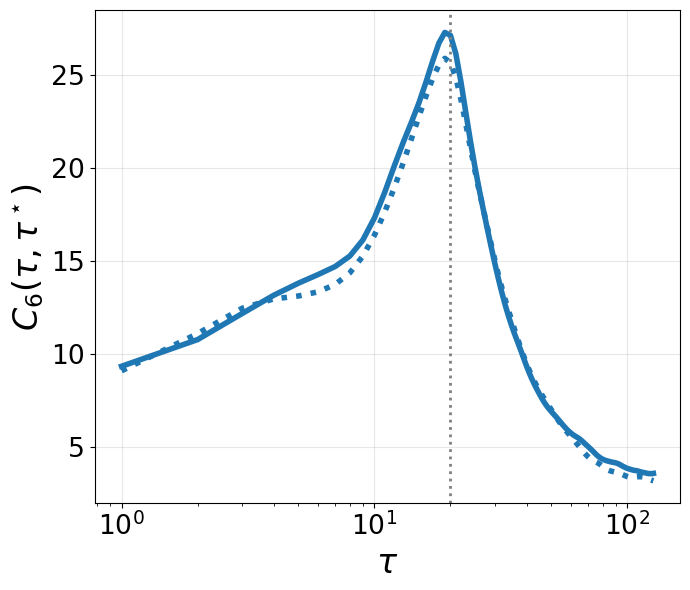

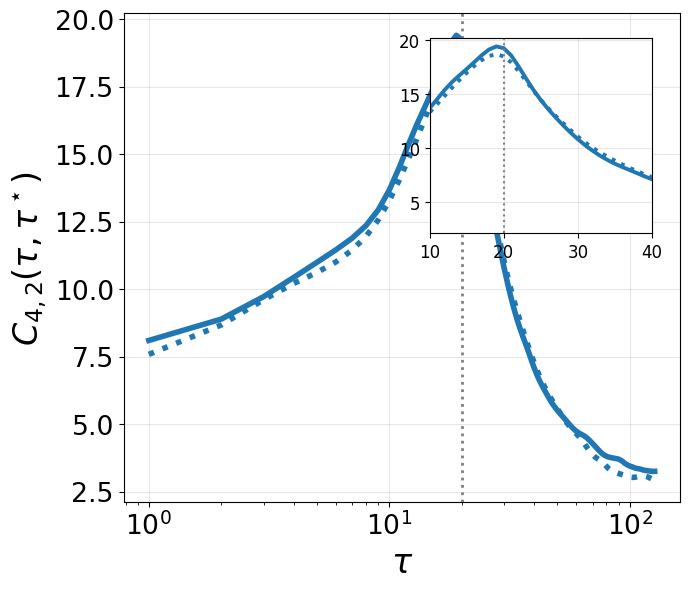

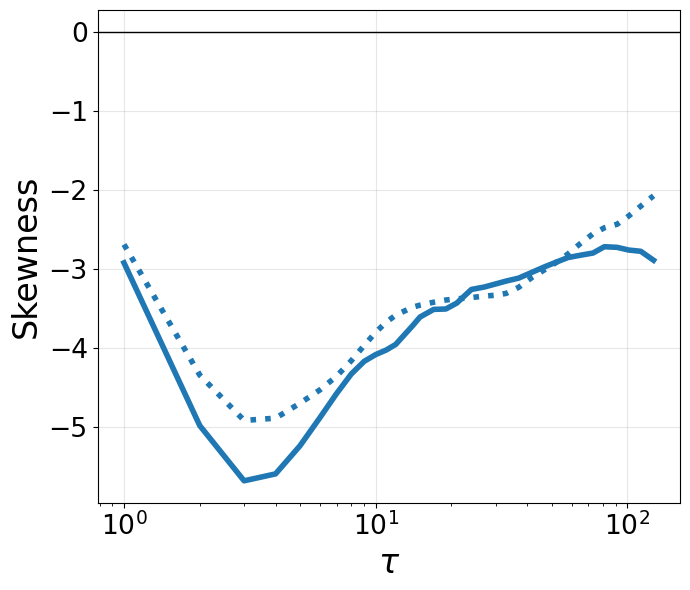

In [24]:
# Usage:
from paper_figures import make_all_panels
#data_E = x1
#synth_E = results[key]["xt"]
data_lagr = x1
synth_lagr = result["xt"]

# Plotting panels using specific turbulence variables
#make_all_panels(data_E, synth_E, data_lagr, synth_lagr, tau_star=20, save_dir=None)          # display
#make_all_panels(data_E, synth_E, data_lagr, synth_lagr, tau_star=20, save_dir='paper_figs/run1')   # save
make_all_panels(data_lagr, synth_lagr, label1="Lagrangian", tau_star=20) #, save_dir='figures/lagrangian')   # save